#Background Removal Using Neural Networks

This notebook explores background estimation and removal in synthetic radio astronomy spectra using deep learning techniques.

The main objective is to train a neural network capable of estimating the smooth background component of a spectrum while ignoring spectral lines and noise.

The workflow includes:

1. Synthetic spectrum generation
2. Signal preprocessing
3. Dataset construction
4. TensorFlow model development
5. Training and evaluation
6. Background subtraction analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from enum import Enum

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from scipy.signal import savgol_filter

# Step 1 — Global Configuration

In this step we configure the global environment of the notebook.

The main objectives are:
- ensuring reproducibility
- configuring plotting settings
- verifying the TensorFlow installation

In [2]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot configuration
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 1 Summary

In this step we configured the notebook environment and initialized reproducibility settings.

Random seeds were fixed for both NumPy and TensorFlow in order to ensure stable and repeatable experiments.

Additionally, default plotting settings were configured to improve visualization consistency throughout the notebook.

# Step 2 — Frequency Axis Generation and Visualization

In this step we generate the synthetic frequency axis that will be used throughout the project.

The selected frequency range is centered near the hydrogen line region around 1420 MHz.

After generating the frequency axis, we visualize it in order to verify:
- the correct number of spectral channels
- the selected frequency range
- the uniform spacing of the samples

In [3]:
NUM_CHANNELS = 1024

FREQ_MIN = 1419.0
FREQ_MAX = 1421.0

freq = np.linspace(FREQ_MIN, FREQ_MAX, NUM_CHANNELS)

print("Frequency axis shape:", freq.shape)
print("Minimum frequency:", freq.min(), "MHz")
print("Maximum frequency:", freq.max(), "MHz")

Frequency axis shape: (1024,)
Minimum frequency: 1419.0 MHz
Maximum frequency: 1421.0 MHz


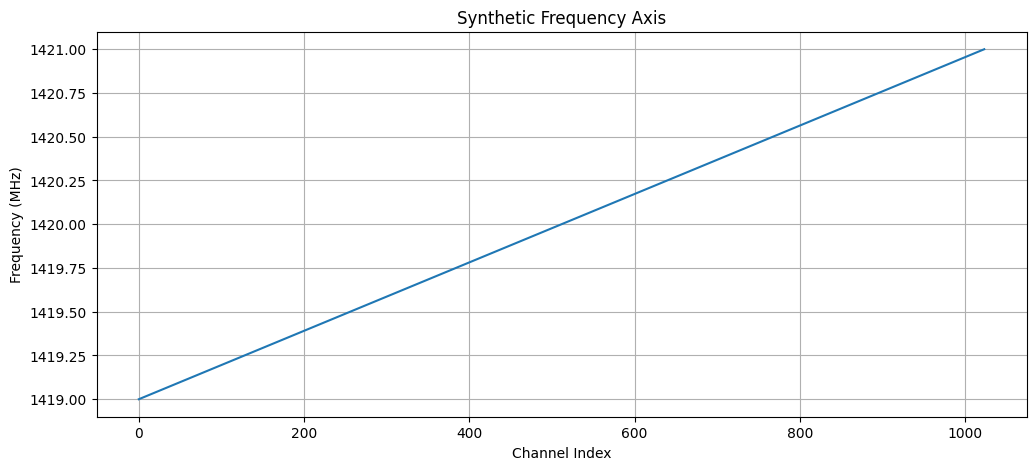

In [4]:
plt.plot(freq)

plt.title("Synthetic Frequency Axis")
plt.xlabel("Channel Index")
plt.ylabel("Frequency (MHz)")

plt.show()

## Step 2 Summary

In this step we generated and visualized the synthetic frequency axis used throughout the entire project.

The generated axis contains 1024 uniformly spaced spectral channels between 1419 MHz and 1421 MHz.

This frequency range is centered near the neutral hydrogen spectral line

# Step 3 — Noise Generation

In this step we generate synthetic Gaussian noise.

Noise is an unavoidable component of real radio astronomy observations and originates from several sources, including:

- receiver electronics,
- thermal fluctuations,
- environmental effects,
- random measurement variations.

For the first version of the pipeline, we assume that noise follows a Gaussian distribution with zero mean.

In [5]:
NOISE_STD = 0.01

noise = np.random.normal(
    loc=0.0,
    scale=NOISE_STD,
    size=NUM_CHANNELS
)

print(f"Noise shape: {noise.shape}")
print(f"Noise mean: {np.mean(noise):.6f}")
print(f"Noise standard deviation: {np.std(noise):.6f}")

Noise shape: (1024,)
Noise mean: 0.000294
Noise standard deviation: 0.009781


## Noise Visualization

Before using the generated noise in the synthetic spectrum pipeline, it is useful to visualize its behavior.

The noise should fluctuate randomly around zero without exhibiting any obvious trend or structure.

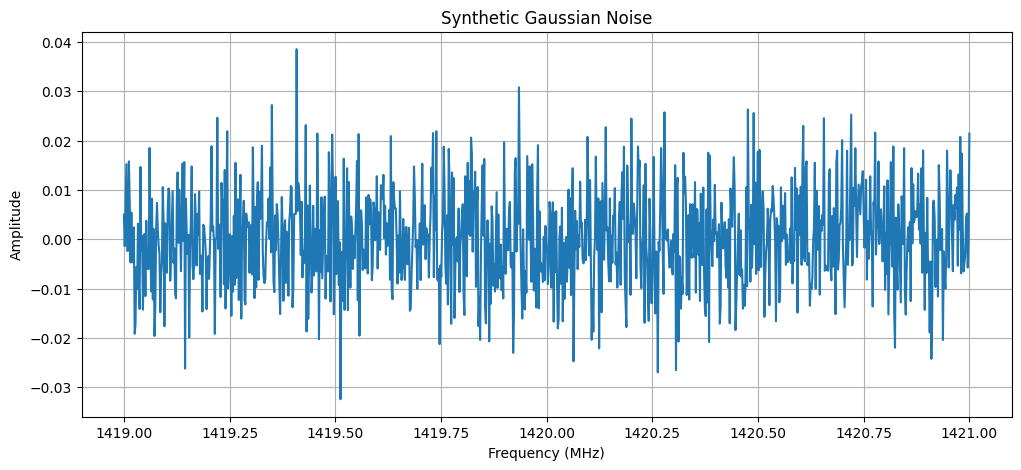

In [6]:
plt.plot(freq, noise)

plt.title("Synthetic Gaussian Noise")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Noise Distribution

A histogram provides a simple way to verify that the generated samples approximately follow a Gaussian distribution.

The distribution should be centered around zero and spread according to the selected standard deviation.

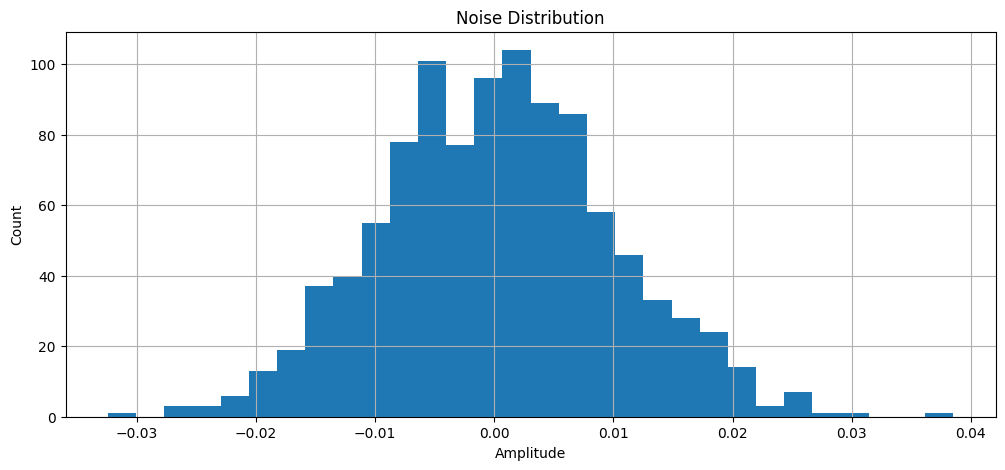

In [7]:
plt.hist(noise, bins=30)

plt.title("Noise Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Count")

plt.show()

## Step 3 Summary

In this step we generated a synthetic Gaussian noise signal with zero mean and a standard deviation of 0.01.

The generated noise contains one value for each spectral channel.

This component will be incorporated into the background generation process and the final synthetic observations.

# Step 4 — Background Baseline Generation

According to the synthetic signal generation procedure described in the project guideline, the first component of the background is a constant baseline level.

The original PICTOR implementation generates a random offset between 0.8 and 1.1 before introducing any polynomial bandpass distortions or standing-wave ripples.

In this step we reproduce that behavior and initialize the background signal using only the baseline component.

This allows us to validate each background component independently before constructing the complete synthetic background model.

In [8]:
baseline_level = np.random.uniform(
    low=0.8,
    high=1.1
)

background = np.full_like(
    freq,
    fill_value=baseline_level
)

print(f"Baseline level: {baseline_level:.4f}")
print(f"Background shape: {background.shape}")

Baseline level: 0.9666
Background shape: (1024,)


## Baseline Visualization

The current background contains only a constant DC offset.

This visualization helps verify that the baseline has the correct amplitude and extends across the full frequency range.

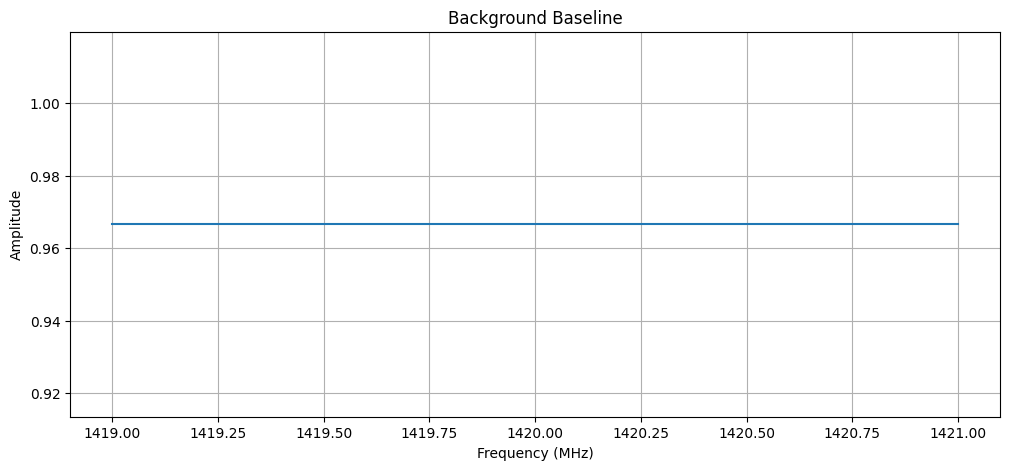

In [9]:
plt.plot(freq, background)

plt.title("Background Baseline")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Step 4 Summary

The background signal has been initialized using a constant baseline level sampled from the range specified in the project guideline.

At this stage the background contains only the DC offset component.


# Step 5 — Background Distortion Configuration

The synthetic background generation procedure supports different large-scale background morphologies.

Three distortion configurations are defined:

- `POLY` for polynomial bandpass variation,
- `SIN` for standing-wave ripple,
- `BOTH` for a combination of the two components.

Before generating these components, the frequency axis is normalized to the interval [-1, 1]. The normalized coordinate is used directly in the polynomial and sinusoidal background equations.

In [10]:
class SignalType(Enum):
    POLY = 1
    SIN = 2
    BOTH = 3

In [11]:
x_norm = (
    2 * (freq - np.min(freq))
    / (np.max(freq) - np.min(freq))
    - 1
)

print(f"Normalized frequency minimum: {x_norm.min():.2f}")
print(f"Normalized frequency maximum: {x_norm.max():.2f}")

Normalized frequency minimum: -1.00
Normalized frequency maximum: 1.00


In [12]:
possible_signals = [
    SignalType.POLY,
    SignalType.SIN,
    SignalType.BOTH
]

signal_type = np.random.choice(
    possible_signals,
    p=[0.2, 0.1, 0.7]
)

print(f"Selected distortion type: {signal_type.name}")

Selected distortion type: BOTH


## Step 5 Summary

The background distortion configuration has been defined using the three signal types required by the synthetic generation procedure.

The frequency axis was normalized to [-1, 1] and a distortion configuration was selected using the predefined probability distribution.

The selected signal type will control whether the synthetic background receives a polynomial component, a sinusoidal ripple, or both in the following steps.

# Step 6 — Polynomial Bandpass Component

The polynomial component introduces the smooth large-scale bandpass variation of the synthetic background.

Following the selected distortion configuration, this component is generated only for `POLY` and `BOTH` background types.

The polynomial is defined using the normalized frequency axis and contains:

- a curvature term controlling the overall U-shaped or hill-shaped morphology,
- a slope term introducing a gradual linear variation across the spectrum.

The parameter ranges follow the PICTOR-inspired synthetic generation procedure.

In [13]:
poly_component = np.zeros_like(freq)

if signal_type in (SignalType.POLY, SignalType.BOTH):
    curvature = np.random.uniform(-0.02, 0.08)
    slope = np.random.uniform(-0.03, 0.03)

    poly_component = (
        curvature * x_norm**2
        + slope * x_norm
    )

    print(f"Curvature: {curvature:.4f}")
    print(f"Slope: {slope:.4f}")

else:
    print("Polynomial component skipped for SIN distortion type.")

Curvature: 0.0028
Slope: 0.0298


## Polynomial Component Visualization

The polynomial component is visualized independently before being combined with the baseline.

This makes it possible to inspect the large-scale morphology introduced by the sampled curvature and slope parameters.

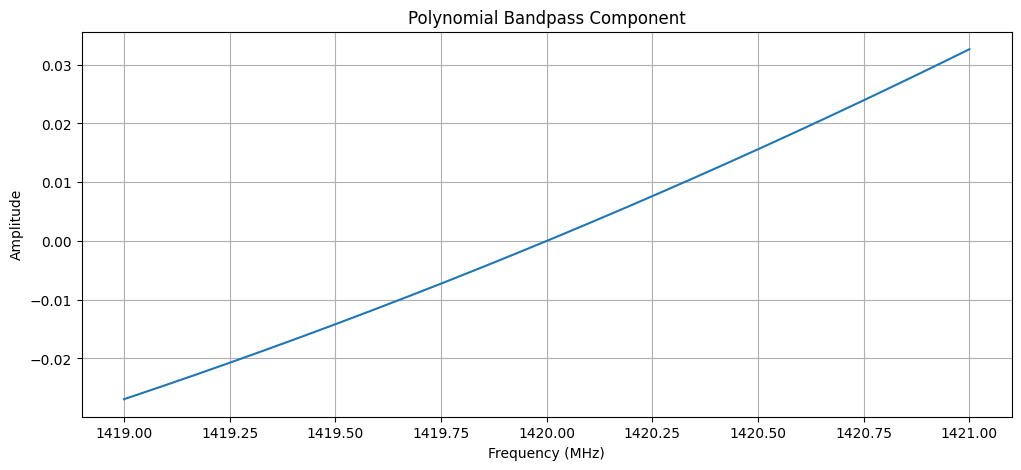

In [14]:
plt.plot(freq, poly_component)

plt.title("Polynomial Bandpass Component")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Polynomial Background Combination

The generated polynomial component is now combined with the baseline background.

A separate background variable is retained at this stage so that each synthetic component remains independently traceable throughout the generation pipeline.

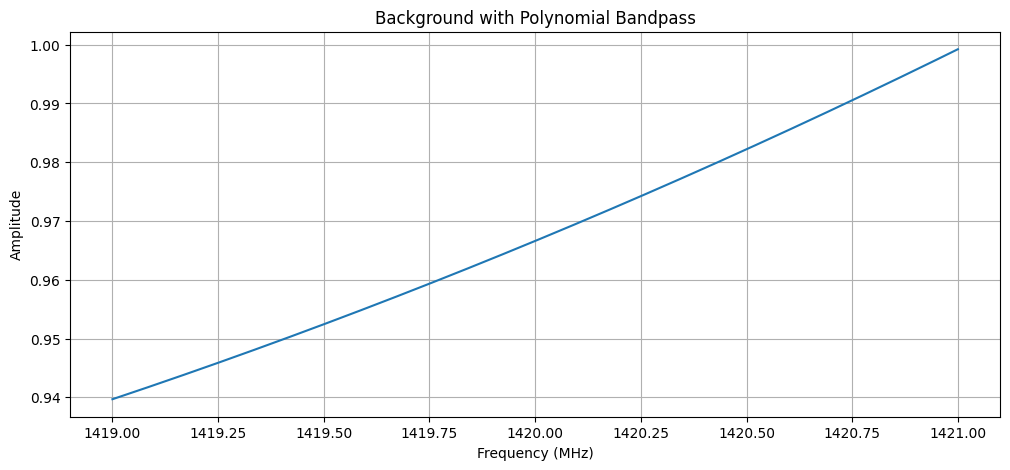

In [15]:
background_with_poly = background + poly_component

plt.plot(freq, background_with_poly)

plt.title("Background with Polynomial Bandpass")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Step 6 Summary

The polynomial bandpass component has been generated according to the selected background distortion type.

For `POLY` and `BOTH` configurations, random curvature and slope parameters were sampled from the ranges defined in the synthetic signal procedure.

The polynomial component was then combined with the baseline while remaining separately available for component-level inspection.

The resulting background now includes the smooth large-scale bandpass variation required for PICTOR-like spectrum generation.

# Step 7 — Standing-Wave Ripple Component

The second distortion component models the standing-wave ripple present in PICTOR-like backgrounds.

According to the selected background configuration, the sinusoidal component is generated only for `SIN` and `BOTH` distortion types.

The ripple amplitude is kept small relative to the baseline, while the number of cycles is restricted to produce broad oscillations across the full spectrum rather than high-frequency variations.

A random phase is also introduced so that the ripple morphology does not begin at the same position in every generated spectrum.

In [16]:
sin_component = np.zeros_like(freq)

if signal_type in (SignalType.SIN, SignalType.BOTH):
    ripple_amplitude = np.random.uniform(0.005, 0.01)
    cycles = np.random.uniform(0.5, 3.0)
    phase = np.random.uniform(0, 2 * np.pi)

    sin_component = ripple_amplitude * np.sin(
        cycles * np.pi * x_norm + phase
    )

    print(f"Ripple amplitude: {ripple_amplitude:.4f}")
    print(f"Cycles: {cycles:.4f}")
    print(f"Phase: {phase:.4f} rad")

else:
    print("Sinusoidal component skipped for POLY distortion type.")

Ripple amplitude: 0.0099
Cycles: 2.1258
Phase: 1.2538 rad


## Ripple Component Visualization

The sinusoidal component is inspected independently before being added to the existing background.

This visualization verifies that the generated ripple remains a low-amplitude, broad oscillation across the frequency range.

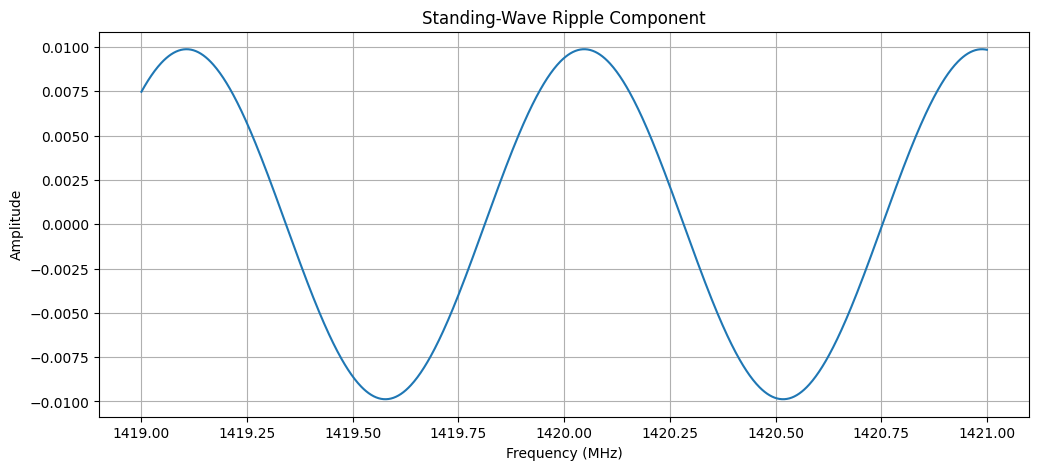

In [17]:
plt.plot(freq, sin_component)

plt.title("Standing-Wave Ripple Component")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Background Component Combination

The standing-wave ripple is now added to the background produced in the previous step.

Because inactive distortion components are represented by zero-valued arrays, the same combination procedure can be used for all three background configurations.

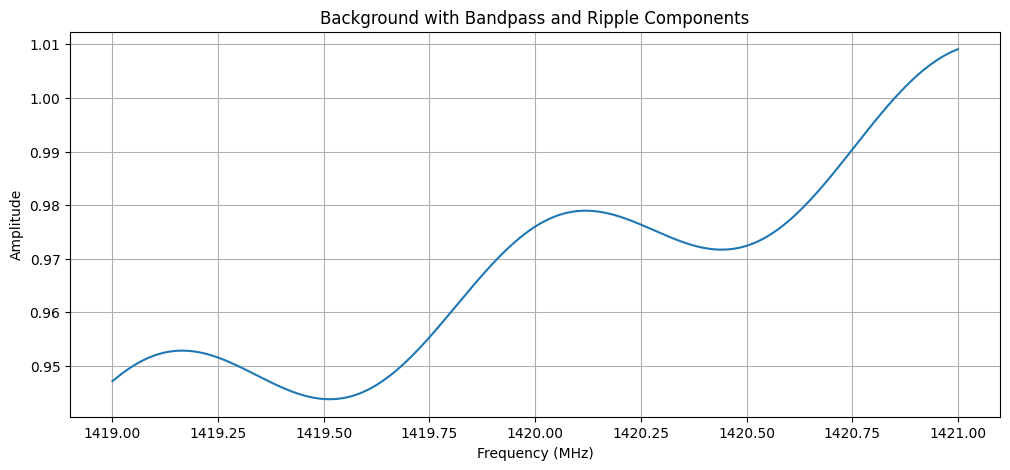

In [18]:
background_with_ripple = background_with_poly + sin_component

plt.plot(freq, background_with_ripple)

plt.title("Background with Bandpass and Ripple Components")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Step 7 Summary

The standing-wave ripple component has been generated for `SIN` and `BOTH` background configurations.

Its amplitude, oscillation scale, and phase were randomly sampled from the ranges defined in the PICTOR-inspired generation procedure.

The sinusoidal component was then combined with the existing background pipeline.

At this stage, the synthetic background contains the baseline and the distortion components selected by the current background configuration.

# Step 8 — Final Synthetic Background Generation

The final stage of the background generation pipeline incorporates the noise signal created in Step 3.

At this point, the deterministic background structure has already been constructed from the baseline and the distortion components selected by `signal_type`.

The previously generated Gaussian noise is now added to this structure, reproducing the final output of the PICTOR-inspired background generation procedure.

The resulting signal will be retained as the synthetic background used in the following spectral-line generation stage.

In [19]:
final_background = background_with_ripple + noise

print(f"Final background shape: {final_background.shape}")
print(f"Final background mean: {np.mean(final_background):.6f}")
print(f"Final background standard deviation: {np.std(final_background):.6f}")

Final background shape: (1024,)
Final background mean: 0.968402
Final background standard deviation: 0.020865


## Final Background Visualization

The completed synthetic background is now visualized across the frequency range.

This plot represents the combined output of the baseline, the selected large-scale distortion components, and the Gaussian noise contribution.

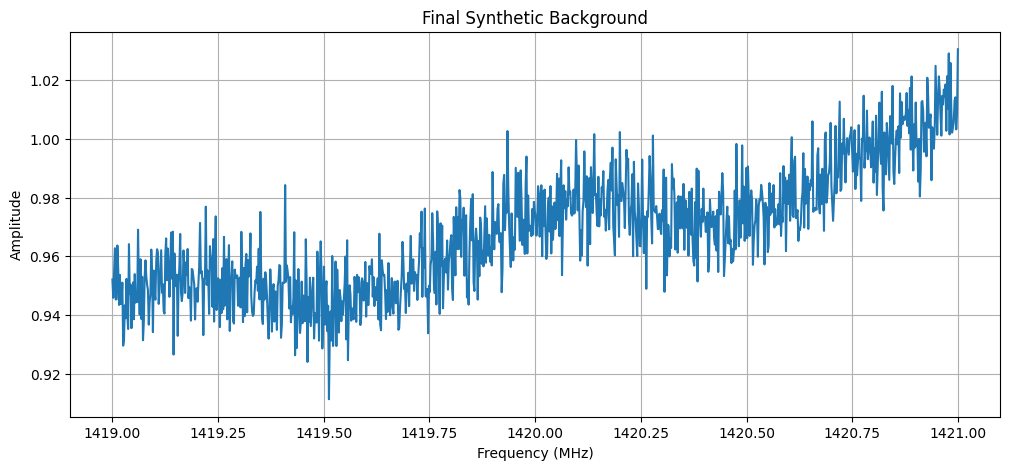

In [20]:
plt.plot(freq, final_background)

plt.title("Final Synthetic Background")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Background Generation Comparison

To verify the contribution of each stage, the intermediate background signals are compared with the final noisy background.

This comparison provides a direct view of how the constant baseline is progressively transformed by the selected distortion components and the final noise contribution.

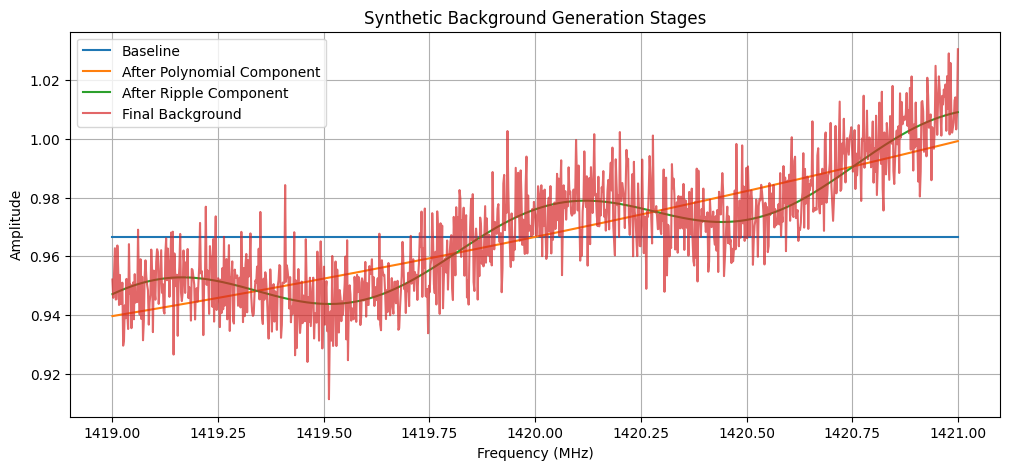

In [21]:
plt.plot(freq, background, label="Baseline")
plt.plot(freq, background_with_poly, label="After Polynomial Component")
plt.plot(freq, background_with_ripple, label="After Ripple Component")
plt.plot(freq, final_background, label="Final Background", alpha=0.7)

plt.title("Synthetic Background Generation Stages")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Step 8 Summary

The synthetic background generation pipeline has been completed by adding the previously generated Gaussian noise.

The final background combines:

- the randomly sampled baseline level,
- the polynomial bandpass component when enabled,
- the standing-wave ripple when enabled,
- the Gaussian noise contribution.

The intermediate and final background signals were also compared to verify the progressive construction of the synthetic PICTOR-like background.

The completed background can now be used as the base signal for synthetic spectral-line generation.

# Step 9 — Main Spectral Peak Generation

The synthetic spectral-line generation stage begins with the construction of the main emission peak.

The spectral-line array is initialized independently from the previously generated background. For each requested spectral line, the central frequency is sampled between 1420.3 and 1420.7 MHz.

The peak width is controlled by a randomly sampled Gaussian standard deviation, while its amplitude is scaled relative to the measured standard deviation of the generated noise.

This SNR-based amplitude definition keeps the spectral-line strength directly linked to the noise conditions of the current synthetic observation.

In [22]:
NUM_SPECTRAL_LINES = 1

noise_std = np.std(noise)

spectral_lines = np.zeros_like(freq)

print(f"Number of spectral lines: {NUM_SPECTRAL_LINES}")
print(f"Measured noise standard deviation: {noise_std:.6f}")

Number of spectral lines: 1
Measured noise standard deviation: 0.009781


## Main Peak Parameter Sampling

Each main peak is modeled using a Gaussian profile.

The center, width, and signal-to-noise ratio are sampled independently within the ranges defined by the synthetic signal procedure.

The sampled SNR is converted into a peak amplitude using the measured noise standard deviation.

In [23]:
for _ in range(NUM_SPECTRAL_LINES):
    # Sample the main spectral-line center
    center_mean = np.random.uniform(1420.3, 1420.7)

    # Sample the Gaussian width and signal-to-noise ratio
    main_sigma = np.random.uniform(0.03, 0.045)
    main_snr = np.random.uniform(1.2, 8.0)

    # Scale the peak amplitude relative to the measured noise level
    main_amp = main_snr * noise_std

    # Generate the main Gaussian peak
    main_line = main_amp * np.exp(
        -((freq - center_mean) ** 2)
        / (2 * main_sigma**2)
    )

    spectral_lines += main_line

print(f"Center frequency: {center_mean:.4f} MHz")
print(f"Main sigma: {main_sigma:.4f}")
print(f"Main SNR: {main_snr:.4f}")
print(f"Main amplitude: {main_amp:.6f}")

Center frequency: 1420.5721 MHz
Main sigma: 0.0311
Main SNR: 1.4084
Main amplitude: 0.013776


## Main Spectral Peak Visualization

The generated main peak is visualized independently from the background.

At this stage, the spectral-line morphology is intentionally symmetric because only the primary Gaussian component has been generated.

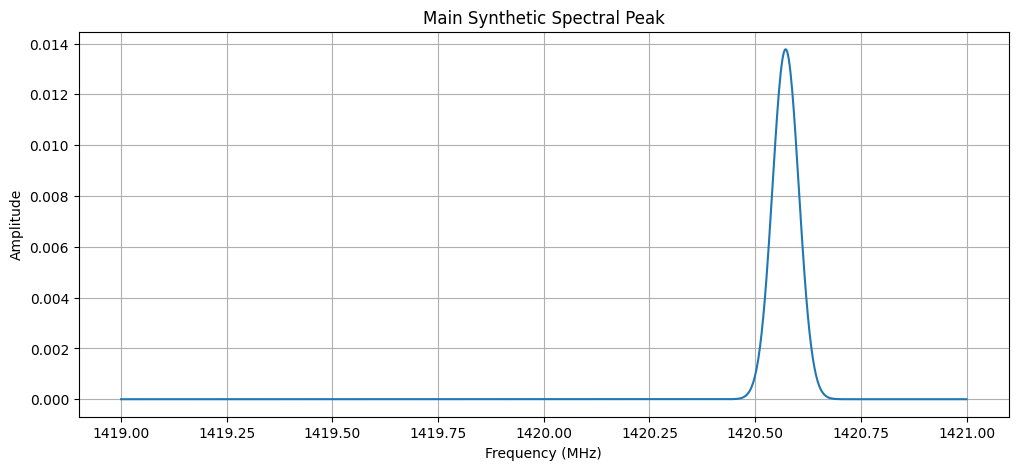

In [24]:
plt.plot(freq, spectral_lines)

plt.title("Main Synthetic Spectral Peak")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Step 9 Summary

The spectral-line generation pipeline has been initialized and the main Gaussian peak has been constructed.

The peak center and width were randomly sampled from the ranges defined by the PICTOR-inspired procedure.

Its amplitude was determined from the sampled SNR and the measured standard deviation of the generated noise, directly linking the spectral-line strength to the noise level of the current synthetic observation.

At this stage, the spectral line contains only the symmetric main peak.

# Step 10 — Secondary Gaussian Component Generation

The main Gaussian peak generated in the previous step produces a smooth and symmetric spectral-line profile.

The synthetic signal procedure introduces additional Gaussian components near the primary peak to create a more irregular and asymmetric morphology.

Each secondary component is independently shifted from the main peak center and assigned its own width and amplitude.

The amplitude of each component is defined as a fraction of the main peak amplitude, ensuring that the primary spectral component remains dominant.

These secondary Gaussian components are generated as a synthetic morphology mechanism and are not related to antenna sidelobes.

In [25]:
num_secondary_components = np.random.randint(3, 7)

secondary_components = np.zeros_like(freq)

for _ in range(num_secondary_components):
    # Sample a local shift relative to the main peak center
    offset = np.random.normal(
        loc=-main_sigma * 0.8,
        scale=main_sigma * 0.8
    )

    secondary_mean = center_mean + offset

    # Sample the component width and relative amplitude
    secondary_sigma = np.random.uniform(0.02, 0.04)
    secondary_amp = (
        np.random.uniform(0.3, 0.6)
        * main_amp
    )

    # Generate the secondary Gaussian component
    secondary_line = secondary_amp * np.exp(
        -((freq - secondary_mean) ** 2)
        / (2 * secondary_sigma**2)
    )

    secondary_components += secondary_line

print(
    f"Number of secondary Gaussian components: "
    f"{num_secondary_components}"
)

Number of secondary Gaussian components: 3


## Secondary Component Visualization

The secondary Gaussian components are visualized independently before being combined with the main spectral peak.

This allows the additional local spectral structure to be inspected separately from the dominant Gaussian component.

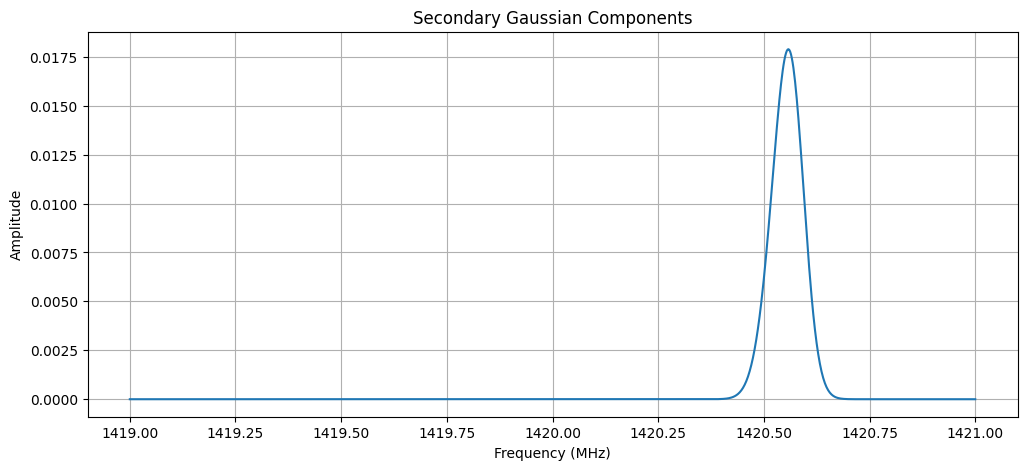

In [26]:
plt.plot(freq, secondary_components)

plt.title("Secondary Gaussian Components")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Spectral-Line Component Combination

The secondary Gaussian components are now added to the main spectral peak.

The resulting profile preserves the dominant primary component while introducing local asymmetry and additional spectral structure.

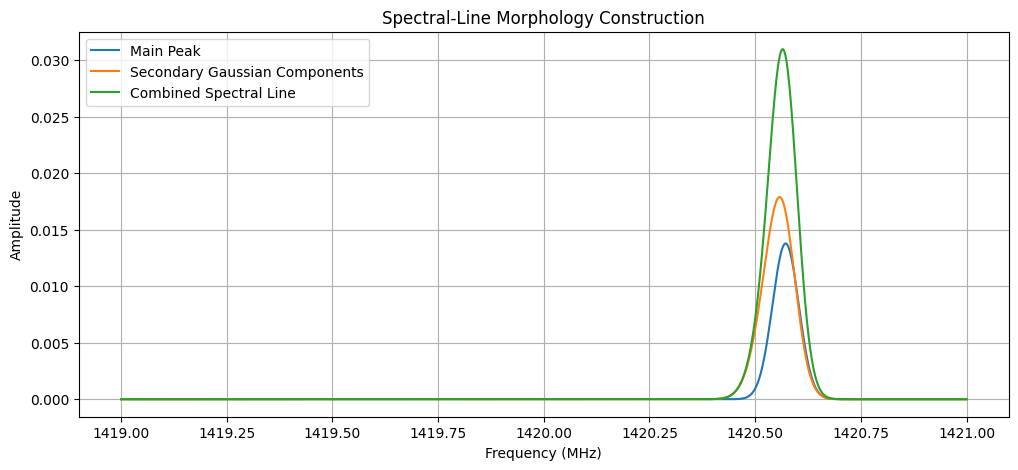

In [27]:
spectral_lines += secondary_components

plt.plot(freq, main_line, label="Main Peak")

plt.plot(freq, secondary_components, label="Secondary Gaussian Components")

plt.plot(freq, spectral_lines, label="Combined Spectral Line")

plt.title("Spectral-Line Morphology Construction")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Step 10 Summary

Several secondary Gaussian components were generated near the main spectral peak.

Each component was assigned an independently sampled center offset, width, and relative amplitude.

The secondary components were then combined with the main Gaussian peak, transforming the original symmetric profile into a more irregular and asymmetric synthetic spectral line.

The resulting morphology follows the multi-component spectral-line construction defined in the PICTOR-inspired generation procedure.

# Step 11 — Spectral-Line Mask Generation

The complete synthetic spectral-line profile is now used to identify the frequency channels associated with the generated line structure.

Following the PICTOR-inspired procedure, a detection threshold is defined relative to the measured noise standard deviation.

Channels where the spectral-line amplitude exceeds half of the noise standard deviation are assigned a mask value of 1. All remaining channels are assigned a value of 0.

The resulting binary mask represents the spectral region that should be excluded when estimating the smooth background.

In [28]:
line_threshold = 0.5 * noise_std

mask = (
    spectral_lines > line_threshold
).astype(float)

print(f"Line threshold: {line_threshold:.6f}")
print(f"Masked channels: {int(np.sum(mask))}")
print(f"Total channels: {len(mask)}")

Line threshold: 0.004890
Masked channels: 71
Total channels: 1024


## Spectral-Line Mask Visualization

The binary mask is visualized across the frequency axis to inspect the region identified as part of the synthetic spectral line.

A mask value of 1 indicates that the spectral-line amplitude exceeds the noise-relative threshold, while a value of 0 represents the remaining frequency channels.

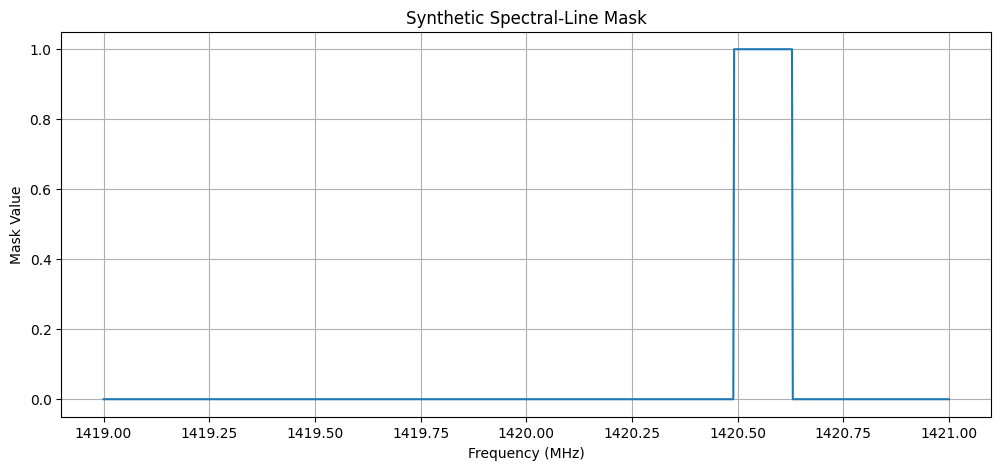

In [29]:
plt.plot(freq, mask)

plt.title("Synthetic Spectral-Line Mask")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Mask Value")

plt.show()

## Spectral-Line Threshold Verification

The generated spectral-line profile is compared directly with the noise-relative threshold.

The masked region corresponds to the frequency channels where the spectral-line amplitude remains above the selected threshold.

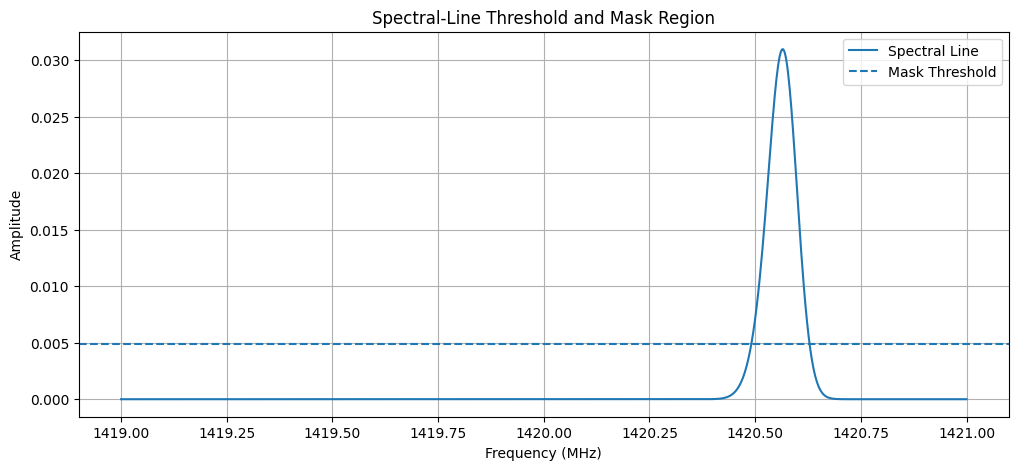

In [30]:
plt.plot(freq, spectral_lines, label="Spectral Line")

plt.axhline(line_threshold, linestyle="--", label="Mask Threshold")

plt.title("Spectral-Line Threshold and Mask Region")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Step 11 Summary

A binary spectral-line mask was generated using a threshold defined as half of the measured noise standard deviation.

Channels exceeding this threshold were identified as part of the synthetic spectral-line region.

The mask provides an explicit representation of the frequency interval influenced by the generated spectral structure and will support the background-removal workflow in the following stages.

# Step 12 — Final Synthetic Observation Generation

The final synthetic observation is constructed by combining the completed background with the generated spectral-line profile.

The background already contains the baseline, the selected polynomial and sinusoidal distortions, and the Gaussian noise contribution.

Therefore, the spectral-line profile is added directly to `final_background` without introducing an additional noise term.

This produces the complete synthetic spectrum that will later be used as the neural network input.

In [31]:
final_signal = final_background + spectral_lines

print(f"Final signal shape: {final_signal.shape}")
print(f"Final signal mean: {np.mean(final_signal):.6f}")
print(f"Final signal standard deviation: {np.std(final_signal):.6f}")
print(f"Final signal minimum: {np.min(final_signal):.6f}")
print(f"Final signal maximum: {np.max(final_signal):.6f}")

Final signal shape: (1024,)
Final signal mean: 0.969777
Final signal standard deviation: 0.022003
Final signal minimum: 0.911385
Final signal maximum: 1.030501


## Final Synthetic Spectrum Visualization

The complete synthetic observation is visualized across the frequency range.

The resulting spectrum contains the background morphology, random noise fluctuations, and the irregular spectral-line structure generated in the previous steps.

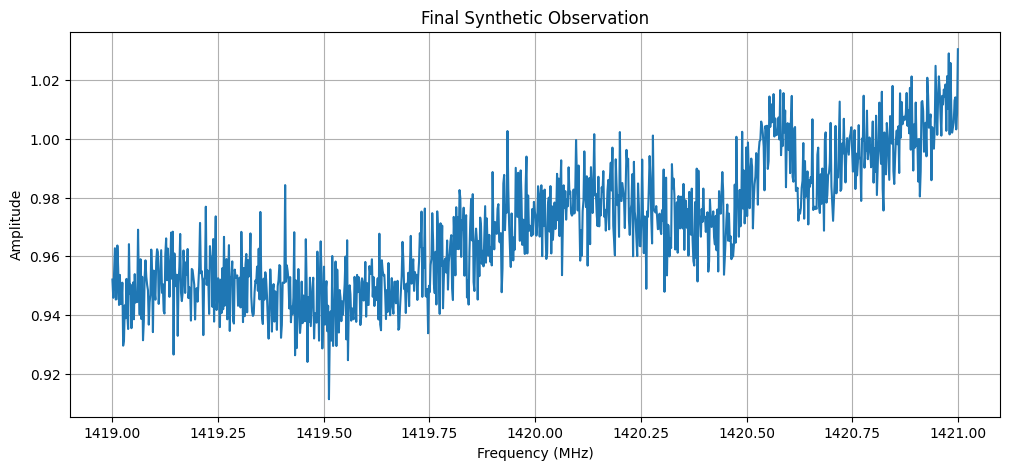

In [32]:
plt.plot(freq, final_signal)

plt.title("Final Synthetic Observation")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Background and Spectral-Line Comparison

The final observation is compared with its two known synthetic components.

Because the data are generated synthetically, the exact background and spectral-line profiles remain available. These signals will later provide the input-target pairs required for supervised neural network training.

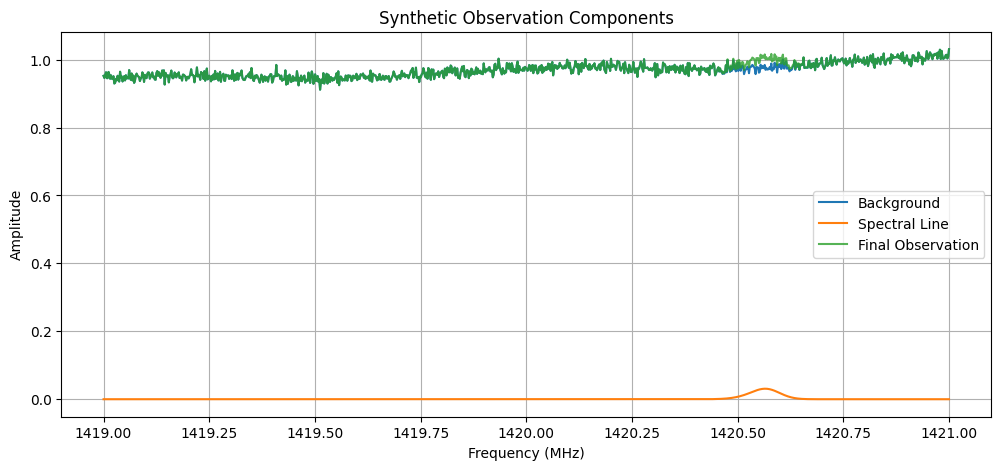

In [33]:
plt.plot(freq, final_background,label="Background")

plt.plot(freq, spectral_lines, label="Spectral Line")

plt.plot(freq, final_signal, label="Final Observation", alpha=0.8)

plt.title("Synthetic Observation Components")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Masked Spectral Region Visualization

The binary mask is overlaid on the final observation to verify the frequency region associated with the synthetic spectral line.

The highlighted area corresponds to channels where the generated spectral-line amplitude exceeds the noise-relative threshold.

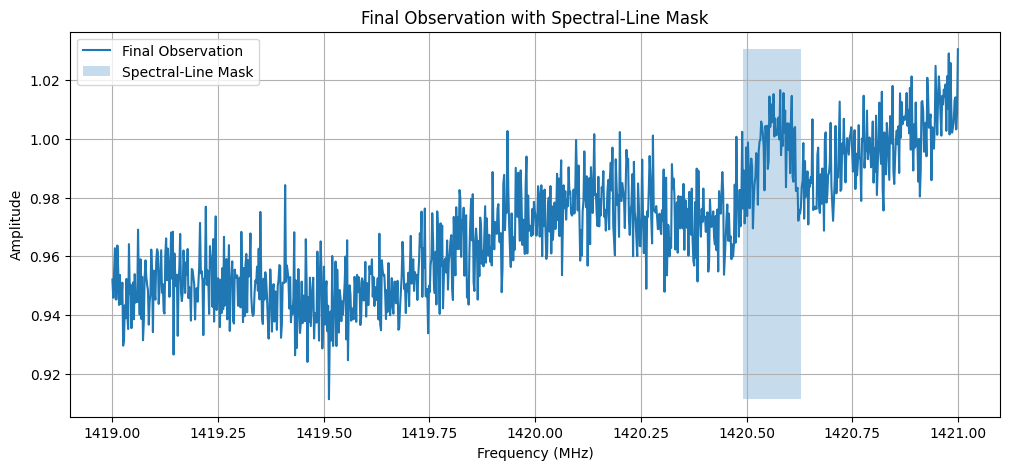

In [34]:
plt.plot(freq, final_signal, label="Final Observation")

plt.fill_between(freq, final_signal.min(), final_signal.max(), where=mask.astype(bool), alpha=0.25, label="Spectral-Line Mask")

plt.title("Final Observation with Spectral-Line Mask")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Step 12 Summary

The complete synthetic observation was generated by adding the irregular spectral-line profile to the final noisy background.

The final observation, its individual synthetic components, and the corresponding spectral-line mask were visualized and verified.

# Step 13 — Signal Smoothing

The preprocessing stage begins by reducing the high-frequency random fluctuations present in the final synthetic observation.

A Savitzky–Golay filter is applied because it performs local polynomial fitting within a moving window. This provides noise reduction while retaining the main morphology of the generated spectral structure.

The raw observation is preserved, and the filtered result is stored separately. This allows the effect of smoothing to be evaluated before deciding whether the raw or smoothed representation should be used during neural network training.

## Smoothing Parameter Configuration

The smoothing window must be large enough to reduce random fluctuations but not so large that it removes or strongly deforms the generated spectral line.

An odd window length of 31 channels and a third-order local polynomial are used as the initial configuration.

These parameters will remain adjustable during later preprocessing experiments.

In [35]:
SAVGOL_WINDOW_LENGTH = 31
SAVGOL_POLYORDER = 3

if SAVGOL_WINDOW_LENGTH % 2 == 0:
    raise ValueError("The Savitzky–Golay window length must be odd.")

if SAVGOL_WINDOW_LENGTH <= SAVGOL_POLYORDER:
    raise ValueError(
        "The window length must be greater than the polynomial order."
    )

if SAVGOL_WINDOW_LENGTH > len(final_signal):
    raise ValueError(
        "The window length cannot exceed the signal length."
    )

channel_spacing = np.mean(np.diff(freq))
smoothing_width_mhz = SAVGOL_WINDOW_LENGTH * channel_spacing

print(f"Window length: {SAVGOL_WINDOW_LENGTH} channels")
print(f"Polynomial order: {SAVGOL_POLYORDER}")
print(f"Channel spacing: {channel_spacing:.6f} MHz")
print(f"Approximate smoothing width: {smoothing_width_mhz:.6f} MHz")

Window length: 31 channels
Polynomial order: 3
Channel spacing: 0.001955 MHz
Approximate smoothing width: 0.060606 MHz


In [36]:
smoothed_signal = savgol_filter(
    final_signal,
    window_length=SAVGOL_WINDOW_LENGTH,
    polyorder=SAVGOL_POLYORDER
)

print(f"Raw signal shape: {final_signal.shape}")
print(f"Smoothed signal shape: {smoothed_signal.shape}")
print(f"Raw signal standard deviation: {np.std(final_signal):.6f}")
print("Smoothed signal standard deviation:", f"{np.std(smoothed_signal):.6f}")

Raw signal shape: (1024,)
Smoothed signal shape: (1024,)
Raw signal standard deviation: 0.022003
Smoothed signal standard deviation: 0.019883


## Raw and Smoothed Signal Comparison

The raw and filtered observations are compared across the complete frequency range.

The filtered signal should follow the large-scale background and spectral-line morphology while exhibiting fewer rapid fluctuations.

The comparison is performed without overwriting the original synthetic observation.

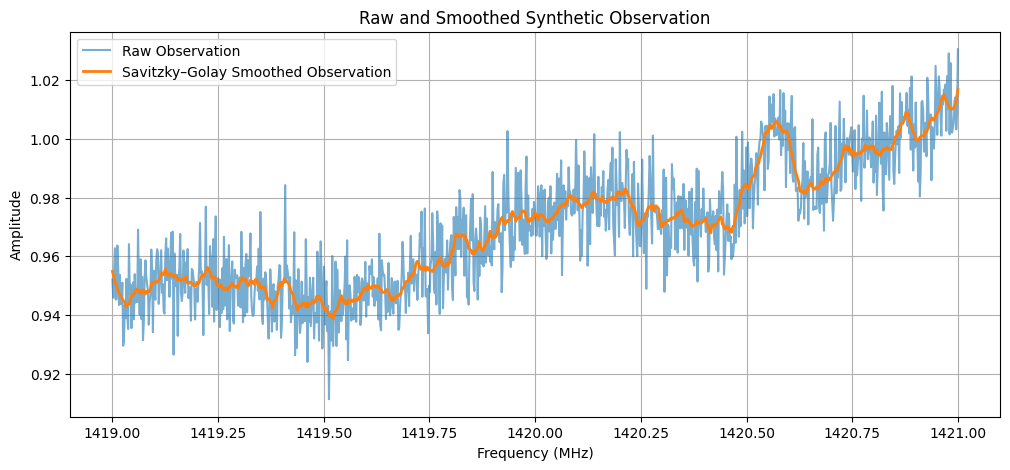

In [37]:
plt.plot(freq, final_signal, label="Raw Observation", alpha=0.6)

plt.plot(freq, smoothed_signal, label="Savitzky–Golay Smoothed Observation", linewidth=2)

plt.title("Raw and Smoothed Synthetic Observation")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Spectral-Region Verification

The spectral-line region is inspected separately to verify that smoothing reduces random fluctuations without removing the main generated structure.

This local comparison is important because excessive smoothing could reduce the peak amplitude, broaden the profile, or remove the secondary Gaussian components.

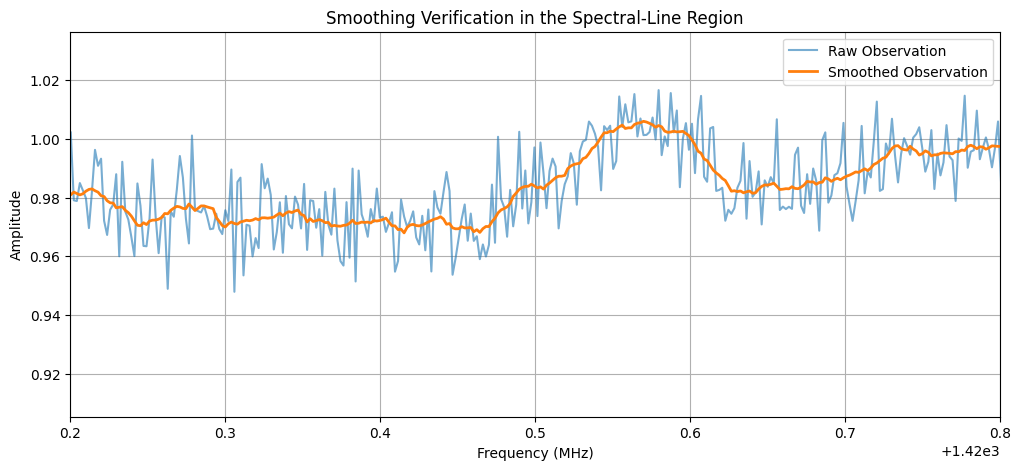

In [38]:
plt.plot(freq, final_signal, label="Raw Observation", alpha=0.6)

plt.plot(freq, smoothed_signal, label="Smoothed Observation", linewidth=2)

plt.xlim(1420.2, 1420.8)

plt.title("Smoothing Verification in the Spectral-Line Region")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Smoothing Residual

The difference between the raw and smoothed observations is calculated to inspect the signal variation removed by the filter.

This residual mainly contains rapid fluctuations, but it should not be interpreted as a pure noise measurement because smoothing may also introduce small differences near the spectral line and curved background regions.

In [39]:
smoothing_residual = final_signal - smoothed_signal

print("Residual mean:", f"{np.mean(smoothing_residual):.10f}")

print("Residual standard deviation:", f"{np.std(smoothing_residual):.6f}")

Residual mean: 0.0000058249
Residual standard deviation: 0.009394


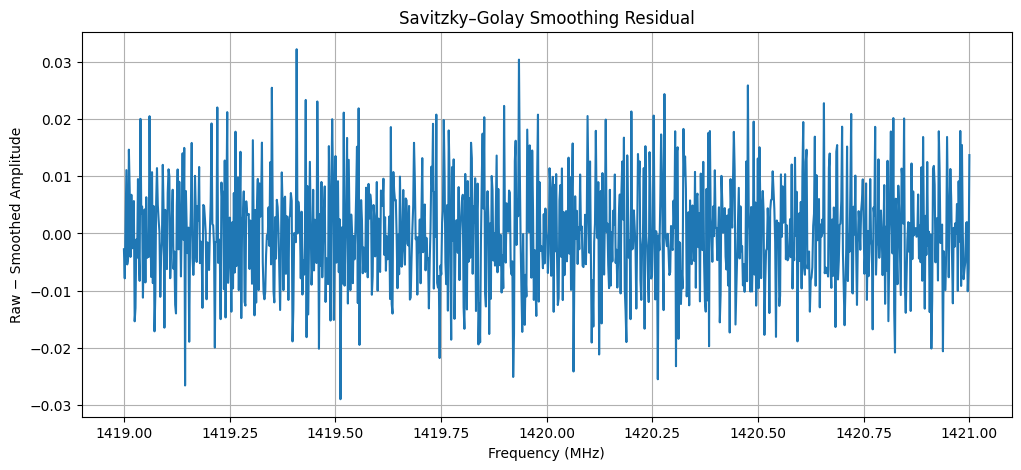

In [40]:
plt.plot(freq, smoothing_residual)

plt.title("Savitzky–Golay Smoothing Residual")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Raw − Smoothed Amplitude")

plt.show()

## Step 13 Summary

A Savitzky–Golay filter was applied to the final synthetic observation using a 31-channel window and a third-order local polynomial.

The original observation was preserved, while the filtered result was stored as a separate preprocessing representation.

The complete spectrum and the spectral-line region were inspected to verify that smoothing reduced rapid fluctuations without removing the dominant generated morphology.

The smoothing residual was also calculated to quantify the variation removed by the filter.

Both the raw and smoothed observations remain available for later preprocessing and model-comparison experiments.

# Step 14 — Z-Score Standardization

The synthetic observations currently contain a baseline near unity, while the spectral-line, ripple, and noise components have considerably smaller amplitudes.

Z-score standardization is applied to center each observation around zero and scale it according to its standard deviation.

Both the raw and Savitzky–Golay filtered observations are standardized independently. This preserves the two preprocessing branches for later model comparison.

The mean and standard deviation used for each transformation are retained because they will be required to:

- transform the corresponding regression target consistently,
- restore predicted backgrounds to their original amplitude scale.

## Standardization Function

A reusable function is defined to apply Z-score standardization safely.

A minimum standard-deviation check prevents division by a value that is zero or numerically too small.

In [41]:
STANDARDIZATION_EPSILON = 1e-8


def z_score_standardize(signal, epsilon=STANDARDIZATION_EPSILON):
    """
    Apply Z-score standardization to a signal.

    Parameters:
    - signal (numpy.ndarray): The input signal to be standardized.
    - epsilon (float): A small value to avoid division by zero or too small values.

    Returns:
    - standardized_signal (numpy.ndarray): The standardized signal.
    - signal_mean (float): The mean of the original signal.
    - signal_std (float): The standard deviation of the original signal.
    """
    signal = np.asarray(signal, dtype=np.float32)

    signal_mean = np.mean(signal)
    signal_std = np.std(signal)

    if signal_std < epsilon:
        raise ValueError(
            "The signal standard deviation is too small "
            "for Z-score standardization."
        )

    standardized_signal = (
        signal - signal_mean
    ) / signal_std

    return standardized_signal, signal_mean, signal_std

## Raw and Smoothed Signal Standardization

The standardization function is applied separately to the raw observation and the smoothed observation.

Separate statistics are stored for each preprocessing branch, allowing both representations to be evaluated independently in later experiments.

In [42]:
(standardized_raw_signal, raw_signal_mean, raw_signal_std) = z_score_standardize(final_signal)

(standardized_smoothed_signal, smoothed_signal_mean, smoothed_signal_std) = z_score_standardize(smoothed_signal)

print(f"Raw signal mean: {raw_signal_mean:.6f}")
print(f"Raw signal standard deviation: {raw_signal_std:.6f}")

print(f"Smoothed signal mean: {smoothed_signal_mean:.6f}")
print(
    "Smoothed signal standard deviation:",
    f"{smoothed_signal_std:.6f}"
)

Raw signal mean: 0.969777
Raw signal standard deviation: 0.022003
Smoothed signal mean: 0.969771
Smoothed signal standard deviation: 0.019883


## Standardization Verification

A correctly standardized signal should have:

- a mean approximately equal to zero,
- a standard deviation approximately equal to one,
- no missing or infinite values.

These checks verify that both preprocessing branches are numerically valid before dataset construction.

In [43]:
print(
    "Standardized raw mean:",
    f"{np.mean(standardized_raw_signal):.6f}"
)

print(
    "Standardized raw standard deviation:",
    f"{np.std(standardized_raw_signal):.6f}"
)

print(
    "Standardized smoothed mean:",
    f"{np.mean(standardized_smoothed_signal):.6f}"
)

print(
    "Standardized smoothed standard deviation:",
    f"{np.std(standardized_smoothed_signal):.6f}"
)

print(
    "Raw signal contains only finite values:",
    np.all(np.isfinite(standardized_raw_signal))
)

print(
    "Smoothed signal contains only finite values:",
    np.all(np.isfinite(standardized_smoothed_signal))
)

Standardized raw mean: -0.000001
Standardized raw standard deviation: 1.000000
Standardized smoothed mean: -0.000001
Standardized smoothed standard deviation: 1.000000
Raw signal contains only finite values: True
Smoothed signal contains only finite values: True


## Standardized Signal Comparison

The standardized raw and smoothed observations are compared on the same scale.

This comparison isolates the effect of smoothing from differences caused by the original signal offset or amplitude range.

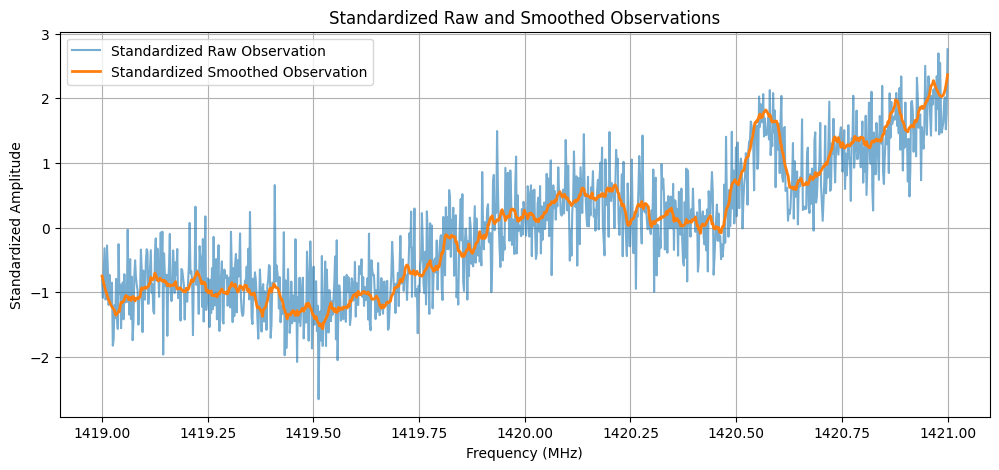

In [44]:
plt.plot(freq, standardized_raw_signal, label="Standardized Raw Observation", alpha=0.6)

plt.plot(freq, standardized_smoothed_signal, label="Standardized Smoothed Observation", linewidth=2)

plt.title("Standardized Raw and Smoothed Observations")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Standardized Amplitude")
plt.legend()

plt.show()

## Standardization Reconstruction Check

The stored mean and standard deviation are used to reconstruct the original smoothed observation.

This check confirms that the standardization process is reversible and that future model predictions can be restored to the original amplitude scale.

In [45]:
reconstructed_smoothed_signal = (standardized_smoothed_signal * smoothed_signal_std + smoothed_signal_mean)

reconstruction_error = np.max(
    np.abs(
        reconstructed_smoothed_signal
        - smoothed_signal
    )
)

print(
    "Maximum reconstruction error:",
    f"{reconstruction_error:.10f}"
)

Maximum reconstruction error: 0.0000000589


## Step 14 Summary

Z-score standardization was applied independently to the raw and smoothed synthetic observations.

Each signal was centered using its own mean and scaled using its own standard deviation.

The standardized representations were verified to have approximately zero mean, unit standard deviation, and only finite values.

The transformation parameters were retained, and an inverse-transformation check confirmed that the original signal scale can be accurately reconstructed.

Both standardized preprocessing branches are now available for later dataset and model-comparison experiments.

# Step 15 — Supervised Input–Target Pair Preparation

The preprocessed signals are now organized into supervised regression pairs for background estimation.

The model input contains the complete synthetic observation, including the generated background, Gaussian noise, and spectral-line structure.

The regression target is the corresponding background before the addition of random noise and spectral components. It therefore contains the baseline and the selected polynomial and sinusoidal distortions.

Two preprocessing branches are retained:

- the standardized raw observation,
- the standardized Savitzky–Golay observation.

For each branch, the target is transformed using the mean and standard deviation of the corresponding input. This places the input and target in the same standardized coordinate system and allows model predictions to be restored to the original amplitude scale.

In [46]:
smooth_background_target = np.asarray(
    background_with_ripple,
    dtype=np.float32
).copy()

## Raw Preprocessing Branch

The standardized raw observation is used as the first model input.

The smooth background target is standardized using the statistics calculated from the raw observation rather than using independent target statistics.

In [47]:
raw_model_input = standardized_raw_signal.copy()

raw_model_target = (
    smooth_background_target - raw_signal_mean
) / raw_signal_std

raw_model_target = raw_model_target.astype(np.float32)

print(f"Raw model input shape: {raw_model_input.shape}")
print(f"Raw model target shape: {raw_model_target.shape}")

Raw model input shape: (1024,)
Raw model target shape: (1024,)


## Smoothed Preprocessing Branch

The standardized Savitzky–Golay observation is used as the second model input.

The same smooth background is transformed using the statistics calculated from the smoothed observation, keeping this preprocessing branch internally consistent.

In [48]:
smoothed_model_input = standardized_smoothed_signal.copy()

smoothed_model_target = (
    smooth_background_target - smoothed_signal_mean
) / smoothed_signal_std

smoothed_model_target = smoothed_model_target.astype(np.float32)

print(
    f"Smoothed model input shape: "
    f"{smoothed_model_input.shape}"
)

print(
    f"Smoothed model target shape: "
    f"{smoothed_model_target.shape}"
)

Smoothed model input shape: (1024,)
Smoothed model target shape: (1024,)


## Raw Input–Target Verification

The standardized raw input is compared with its corresponding background target.

The difference between the two curves represents the standardized contribution of the spectral line and Gaussian noise.

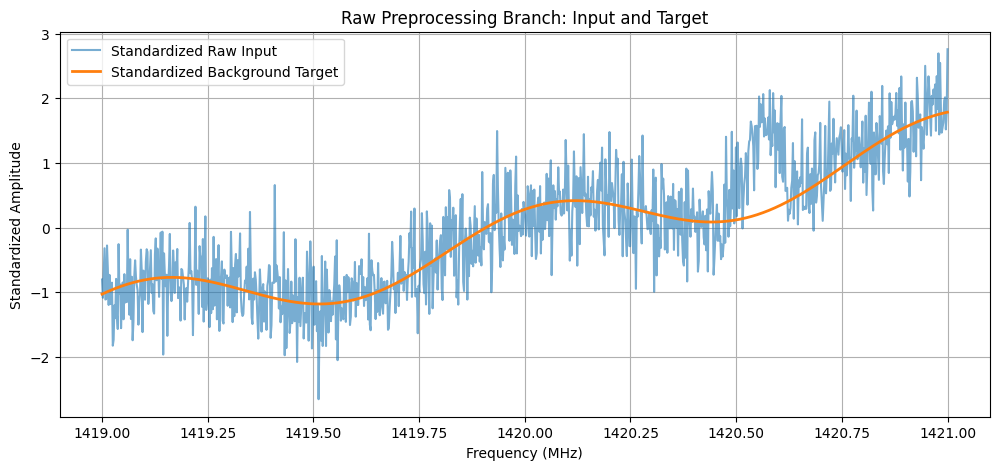

In [49]:
plt.plot(freq, raw_model_input, label="Standardized Raw Input", alpha=0.6)

plt.plot(freq, raw_model_target, label="Standardized Background Target", linewidth=2)

plt.title("Raw Preprocessing Branch: Input and Target")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Standardized Amplitude")
plt.legend()

plt.show()

## Smoothed Input–Target Verification

The standardized smoothed input is compared with the background target transformed using the same preprocessing statistics.

This branch allows the effect of Savitzky–Golay smoothing on the future background-estimation model to be evaluated independently.

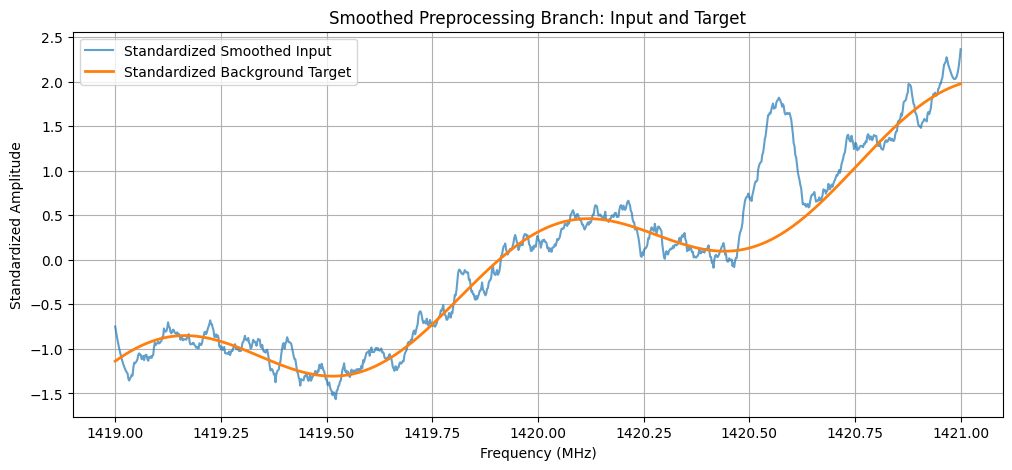

In [50]:
plt.plot(freq, smoothed_model_input, label="Standardized Smoothed Input", alpha=0.7)

plt.plot(freq, smoothed_model_target, label="Standardized Background Target", linewidth=2)

plt.title("Smoothed Preprocessing Branch: Input and Target")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Standardized Amplitude")
plt.legend()

plt.show()

## Input–Target Validation

The generated arrays are checked for matching shapes and valid numerical values before they are incorporated into a larger dataset.

In [51]:
assert raw_model_input.shape == raw_model_target.shape
assert smoothed_model_input.shape == smoothed_model_target.shape

assert np.all(np.isfinite(raw_model_input))
assert np.all(np.isfinite(raw_model_target))

assert np.all(np.isfinite(smoothed_model_input))
assert np.all(np.isfinite(smoothed_model_target))

print("Raw input–target pair is valid.")
print("Smoothed input–target pair is valid.")

Raw input–target pair is valid.
Smoothed input–target pair is valid.


## Target Reconstruction Check

The standardized targets are transformed back to the original amplitude scale.

Both reconstructed targets should match the original smooth background, confirming that the preprocessing transformation is reversible.

In [52]:
reconstructed_raw_target = (
    raw_model_target * raw_signal_std
    + raw_signal_mean
)

reconstructed_smoothed_target = (
    smoothed_model_target * smoothed_signal_std
    + smoothed_signal_mean
)

raw_target_error = np.max(
    np.abs(
        reconstructed_raw_target
        - smooth_background_target
    )
)

smoothed_target_error = np.max(
    np.abs(
        reconstructed_smoothed_target
        - smooth_background_target
    )
)

print(
    "Maximum raw-target reconstruction error:",
    f"{raw_target_error:.10f}"
)

print(
    "Maximum smoothed-target reconstruction error:",
    f"{smoothed_target_error:.10f}"
)

Maximum raw-target reconstruction error: 0.0000000000
Maximum smoothed-target reconstruction error: 0.0000000000


## Step 15 Summary

The synthetic observation and its known smooth background were organized into supervised regression pairs.

The complete observation was assigned as the model input, while the background before noise and spectral-line addition was assigned as the target.

Separate raw and Savitzky–Golay preprocessing branches were retained.

For each branch, the target was standardized using the corresponding input statistics, ensuring consistent scaling and reversible model outputs.

The generated input–target pairs were validated for matching dimensions, finite values, and accurate inverse transformation.

# Step 16 — Reusable Synthetic Sample Generation Functions

The validated synthetic signal pipeline is now reorganized into reusable functions.

The background and spectral-line generation stages are separated so that their components remain independently accessible. A third function combines their outputs into a complete synthetic observation.

Each generated sample retains:

- the smooth background before noise addition,
- the noisy background,
- the complete spectral-line profile,
- the binary spectral-line mask,
- the final synthetic observation.

This modular structure will support large-scale dataset generation while preserving the component-level information required for supervised background estimation.

## Background Generation Function

The background function reproduces the validated baseline, polynomial, ripple, and noise generation procedure.

It returns both the smooth background and its noisy version. Keeping these outputs separate is essential because the smooth background will later serve as the regression target.

In [53]:
def generate_pictor_background(freq, noise_std=0.01, rng=None):
    """
    Generate one PICTOR-like synthetic background.

    Parameters
    ----------
    freq : np.ndarray
        One-dimensional frequency axis.
    noise_std : float
        Standard deviation of the generated Gaussian noise.
    rng : np.random.Generator, optional
        NumPy random number generator used for reproducibility.

    Returns
    -------
    dict
        Generated background arrays, selected distortion type,
        and sampled background parameters.
    """
    if rng is None:
        rng = np.random.default_rng()

    freq = np.asarray(freq, dtype=np.float32)

    if freq.ndim != 1:
        raise ValueError("The frequency axis must be one-dimensional.")

    if freq.size < 2:
        raise ValueError(
            "The frequency axis must contain at least two channels."
        )

    if np.max(freq) == np.min(freq):
        raise ValueError(
            "The frequency axis must contain a non-zero frequency range."
        )

    if noise_std <= 0:
        raise ValueError(
            "The noise standard deviation must be positive."
        )

    # Generate one Gaussian noise realization for the observation
    noise = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=freq.shape
    ).astype(np.float32)

    # Normalize the frequency axis for stable component generation
    x_norm = (
        2 * (freq - np.min(freq))
        / (np.max(freq) - np.min(freq))
        - 1
    ).astype(np.float32)

    # Initialize the constant baseline component
    baseline_level = rng.uniform(0.8, 1.1)

    baseline = np.full(
        freq.shape,
        fill_value=baseline_level,
        dtype=np.float32
    )

    # Select the background distortion configuration
    possible_signals = np.array(
        [
            SignalType.POLY,
            SignalType.SIN,
            SignalType.BOTH
        ],
        dtype=object
    )

    signal_type = rng.choice(
        possible_signals,
        p=[0.2, 0.1, 0.7]
    )

    poly_component = np.zeros_like(freq, dtype=np.float32)
    sin_component = np.zeros_like(freq, dtype=np.float32)

    curvature = None
    slope = None
    ripple_amplitude = None
    cycles = None
    phase = None

    # Generate the polynomial bandpass when enabled
    if signal_type in (SignalType.POLY, SignalType.BOTH):
        curvature = rng.uniform(-0.02, 0.08)
        slope = rng.uniform(-0.03, 0.03)

        poly_component = (
            curvature * x_norm**2
            + slope * x_norm
        ).astype(np.float32)

    # Generate the standing-wave ripple when enabled
    if signal_type in (SignalType.SIN, SignalType.BOTH):
        ripple_amplitude = rng.uniform(0.005, 0.01)
        cycles = rng.uniform(0.5, 3.0)
        phase = rng.uniform(0.0, 2 * np.pi)

        sin_component = (
            ripple_amplitude
            * np.sin(cycles * np.pi * x_norm + phase)
        ).astype(np.float32)

    # Preserve the clean background as the future regression target
    smooth_background = (
        baseline
        + poly_component
        + sin_component
    ).astype(np.float32)

    # Add noise once to obtain the observed background
    final_background = (
        smooth_background
        + noise
    ).astype(np.float32)

    return {
        "x_norm": x_norm,
        "baseline": baseline,
        "poly_component": poly_component,
        "sin_component": sin_component,
        "smooth_background": smooth_background,
        "noise": noise,
        "final_background": final_background,
        "signal_type": signal_type,
        "baseline_level": float(baseline_level),
        "curvature": curvature,
        "slope": slope,
        "ripple_amplitude": ripple_amplitude,
        "cycles": cycles,
        "phase": phase
    }

## Spectral-Line Generation Function

The spectral-line function generates one or more primary Gaussian peaks together with the secondary Gaussian components used to introduce local asymmetry.

The peak amplitude is scaled using the measured standard deviation of the noise realization associated with the same observation.

The complete spectral profile is then converted into a binary mask using the noise-relative threshold defined in the validated generation procedure.

In [54]:
def generate_spectral_lines(freq, noise, num_spectral_lines=1, rng=None):
    """
    Generate synthetic spectral lines and their binary mask.

    Parameters
    ----------
    freq : np.ndarray
        One-dimensional frequency axis.
    noise : np.ndarray
        Noise realization associated with the same observation.
    num_spectral_lines : int
        Number of primary spectral-line structures to generate.
    rng : np.random.Generator, optional
        NumPy random number generator used for reproducibility.

    Returns
    -------
    dict
        Main components, secondary components, complete spectral
        profile, mask, threshold, and sampled line parameters.
    """
    if rng is None:
        rng = np.random.default_rng()

    freq = np.asarray(freq, dtype=np.float32)
    noise = np.asarray(noise, dtype=np.float32)

    if freq.ndim != 1 or noise.ndim != 1:
        raise ValueError(
            "The frequency and noise arrays must be one-dimensional."
        )

    if freq.shape != noise.shape:
        raise ValueError(
            "The frequency and noise arrays must have matching shapes."
        )

    if (
        not isinstance(num_spectral_lines, int)
        or num_spectral_lines < 1
    ):
        raise ValueError(
            "The number of spectral lines must be a positive integer."
        )

    measured_noise_std = float(np.std(noise))

    if measured_noise_std <= 0:
        raise ValueError(
            "The measured noise standard deviation must be positive."
        )

    main_components = np.zeros_like(freq, dtype=np.float32)
    secondary_components = np.zeros_like(freq, dtype=np.float32)

    line_parameters = []

    for _ in range(num_spectral_lines):
        # Sample the primary Gaussian peak parameters
        center_mean = rng.uniform(1420.3, 1420.7)
        main_sigma = rng.uniform(0.03, 0.045)
        main_snr = rng.uniform(1.2, 8.0)
        main_amp = main_snr * measured_noise_std

        main_line = (
            main_amp
            * np.exp(
                -((freq - center_mean) ** 2)
                / (2 * main_sigma**2)
            )
        ).astype(np.float32)

        main_components += main_line

        # Generate 3–6 secondary Gaussian components
        num_secondary_components = int(rng.integers(3, 7))

        current_secondary_components = np.zeros_like(
            freq,
            dtype=np.float32
        )

        secondary_parameters = []

        for _ in range(num_secondary_components):
            offset = rng.normal(
                loc=-main_sigma * 0.8,
                scale=main_sigma * 0.8
            )

            secondary_mean = center_mean + offset
            secondary_sigma = rng.uniform(0.02, 0.04)

            secondary_amp = (
                rng.uniform(0.3, 0.6)
                * main_amp
            )

            secondary_line = (
                secondary_amp
                * np.exp(
                    -((freq - secondary_mean) ** 2)
                    / (2 * secondary_sigma**2)
                )
            ).astype(np.float32)

            current_secondary_components += secondary_line

            secondary_parameters.append(
                {
                    "mean": float(secondary_mean),
                    "sigma": float(secondary_sigma),
                    "amplitude": float(secondary_amp)
                }
            )

        secondary_components += current_secondary_components

        line_parameters.append(
            {
                "center_mean": float(center_mean),
                "main_sigma": float(main_sigma),
                "main_snr": float(main_snr),
                "main_amplitude": float(main_amp),
                "secondary_components": secondary_parameters
            }
        )

    spectral_lines = (
        main_components
        + secondary_components
    ).astype(np.float32)

    line_threshold = 0.5 * measured_noise_std

    mask = (
        spectral_lines > line_threshold
    ).astype(np.float32)

    return {
        "main_components": main_components,
        "secondary_components": secondary_components,
        "spectral_lines": spectral_lines,
        "mask": mask,
        "line_threshold": float(line_threshold),
        "measured_noise_std": measured_noise_std,
        "line_parameters": line_parameters
    }

## Complete Synthetic Sample Function

The complete sample function coordinates the background and spectral-line generators using the same random number generator.

The final observation is constructed by adding the spectral-line profile to the noisy background. Noise is not added again because it is already contained in `final_background`.

The raw final observation is assigned as the model input, while the smooth background is retained as the clean regression target.

In [55]:
def generate_synthetic_sample(freq, noise_std=0.01, num_spectral_lines=1, seed=None):
    """
    Generate one complete supervised synthetic sample.

    Parameters
    ----------
    freq : np.ndarray
        One-dimensional frequency axis.
    noise_std : float
        Standard deviation used for Gaussian noise generation.
    num_spectral_lines : int
        Number of primary spectral-line structures.
    seed : int, optional
        Seed used to reproduce the generated sample.

    Returns
    -------
    dict
        Complete synthetic observation, clean target, mask,
        components, and generation metadata.
    """
    rng = np.random.default_rng(seed)

    background_data = generate_pictor_background(
        freq=freq,
        noise_std=noise_std,
        rng=rng
    )

    spectral_data = generate_spectral_lines(
        freq=freq,
        noise=background_data["noise"],
        num_spectral_lines=num_spectral_lines,
        rng=rng
    )

    final_signal = (
        background_data["final_background"]
        + spectral_data["spectral_lines"]
    ).astype(np.float32)

    return {
        "model_input": final_signal.copy(),
        "model_target": (
            background_data["smooth_background"].copy()
        ),
        "final_signal": final_signal,
        "mask": spectral_data["mask"],
        "background": background_data,
        "spectral": spectral_data
    }

## Reusable Pipeline Verification

A single sample is generated using a fixed seed to verify that the reusable functions reproduce the expected signal structure.

The final observation must be equal to the sum of:

- the smooth background,
- the Gaussian noise realization,
- the complete spectral-line profile.

In [56]:
test_sample = generate_synthetic_sample(freq=freq, noise_std=NOISE_STD, num_spectral_lines=NUM_SPECTRAL_LINES, seed=42)

test_input = test_sample["model_input"]
test_target = test_sample["model_target"]
test_mask = test_sample["mask"]

print(f"Input shape: {test_input.shape}")
print(f"Target shape: {test_target.shape}")
print(f"Mask shape: {test_mask.shape}")

print(
    "Selected distortion type:",
    test_sample["background"]["signal_type"].name
)

print(
    "Measured noise standard deviation:",
    f"{test_sample['spectral']['measured_noise_std']:.6f}"
)

print(
    "Masked channels:",
    int(np.sum(test_mask))
)

Input shape: (1024,)
Target shape: (1024,)
Mask shape: (1024,)
Selected distortion type: BOTH
Measured noise standard deviation: 0.009833
Masked channels: 84


## Component Reconstruction Check

The complete synthetic observation is reconstructed directly from its stored components.

A negligible reconstruction error confirms that no component is missing and that the noise contribution has been included exactly once.

In [57]:
reconstructed_test_signal = (
    test_sample["background"]["smooth_background"]
    + test_sample["background"]["noise"]
    + test_sample["spectral"]["spectral_lines"]
)

test_reconstruction_error = np.max(
    np.abs(
        test_sample["final_signal"]
        - reconstructed_test_signal
    )
)

print(
    "Maximum component reconstruction error:",
    f"{test_reconstruction_error:.10f}"
)

Maximum component reconstruction error: 0.0000000000


## Generated Sample Visualization

The generated model input is compared with its known smooth background target.

The shaded region represents the frequency channels identified by the spectral-line mask.

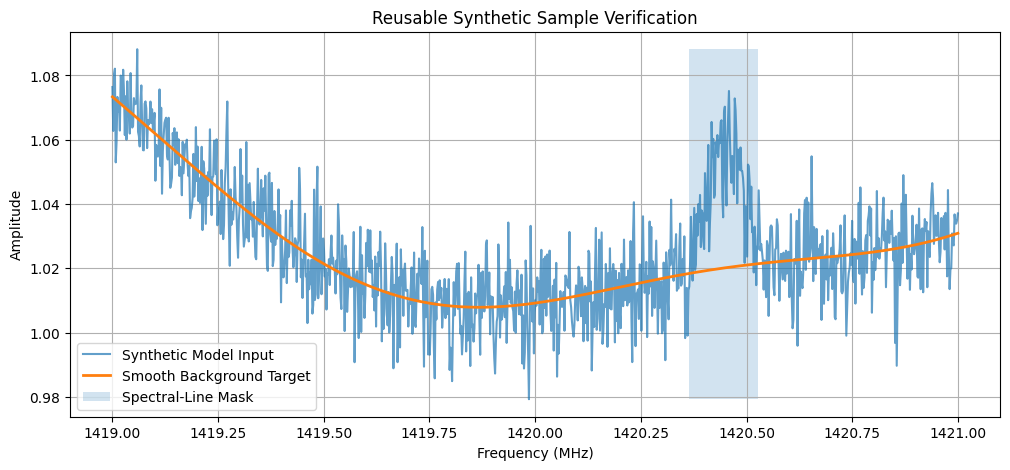

In [58]:
plt.plot(freq, test_input, label="Synthetic Model Input", alpha=0.7)

plt.plot(freq, test_target, label="Smooth Background Target", linewidth=2)

plt.fill_between(freq, np.min(test_input), np.max(test_input), where=test_mask.astype(bool), alpha=0.2, label="Spectral-Line Mask")

plt.title("Reusable Synthetic Sample Verification")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Step 16 Summary

The validated signal-generation workflow was converted into reusable background, spectral-line, and complete-sample functions.

The functions preserve the individual physical and synthetic components of each observation while providing a direct supervised regression pair.

A fixed-seed test sample was generated and checked for matching array dimensions, valid component composition, and single noise inclusion.

The reusable generator is now ready to produce a multi-sample dataset for training, validation, and testing.

# Step 17 — Multi-Sample Synthetic Dataset Generation

The validated sample generator is now used to construct a multi-observation synthetic dataset.

Each dataset entry contains:

- a complete synthetic observation consisting of background, noise, and spectral-line structure,
- the corresponding smooth background target,
- the binary spectral-line mask,
- the selected background distortion type.

The dataset is generated using a dedicated random seed so that the complete collection of synthetic observations can be reproduced independently of the random states used during the earlier single-sample development steps.

The generated arrays will remain in their original amplitude scale at this stage. Smoothing, standardization, and dataset splitting will be applied after the dataset structure has been verified.

## Dataset Configuration

The initial dataset size and generation parameters are defined explicitly so that they can be adjusted without modifying the generation loop.

A fixed dataset seed is used to produce a reproducible sequence of independently generated synthetic observations.

In [59]:
NUM_SAMPLES = 5000
DATASET_SEED = 42

dataset_rng = np.random.default_rng(DATASET_SEED)

sample_seeds = dataset_rng.integers(
    low=0,
    high=np.iinfo(np.uint32).max,
    size=NUM_SAMPLES,
    dtype=np.uint32
)

print(f"Number of samples: {NUM_SAMPLES}")
print(f"Channels per sample: {NUM_CHANNELS}")
print(f"Dataset seed: {DATASET_SEED}")

Number of samples: 5000
Channels per sample: 1024
Dataset seed: 42


## Dataset Array Initialization

The dataset arrays are preallocated before generation.

Using fixed `float32` arrays avoids repeatedly expanding Python lists and keeps the generated data directly compatible with the numerical format commonly used by TensorFlow.

The inputs, targets, and masks all preserve the original number of spectral channels.

In [60]:
X_raw = np.empty(
    (NUM_SAMPLES, NUM_CHANNELS),
    dtype=np.float32
)

y_smooth = np.empty(
    (NUM_SAMPLES, NUM_CHANNELS),
    dtype=np.float32
)

masks = np.empty(
    (NUM_SAMPLES, NUM_CHANNELS),
    dtype=np.float32
)

distortion_types = np.empty(
    NUM_SAMPLES,
    dtype="<U4"
)

measured_noise_std = np.empty(
    NUM_SAMPLES,
    dtype=np.float32
)

## Synthetic Dataset Generation

Each sample is generated independently using one of the reproducible sample seeds.

The resulting observation, smooth background, mask, background morphology, and measured noise level are stored directly in the preallocated dataset arrays.

In [61]:
for sample_idx, sample_seed in enumerate(sample_seeds):
    sample = generate_synthetic_sample(
        freq=freq,
        noise_std=NOISE_STD,
        num_spectral_lines=NUM_SPECTRAL_LINES,
        seed=int(sample_seed)
    )

    X_raw[sample_idx] = sample["model_input"]
    y_smooth[sample_idx] = sample["model_target"]
    masks[sample_idx] = sample["mask"]

    distortion_types[sample_idx] = (
        sample["background"]["signal_type"].name
    )

    measured_noise_std[sample_idx] = (
        sample["spectral"]["measured_noise_std"]
    )

    if (
        (sample_idx + 1) % 500 == 0
        or sample_idx + 1 == NUM_SAMPLES
    ):
        print(
            f"Generated {sample_idx + 1}/{NUM_SAMPLES} samples"
        )

Generated 500/5000 samples
Generated 1000/5000 samples
Generated 1500/5000 samples
Generated 2000/5000 samples
Generated 2500/5000 samples
Generated 3000/5000 samples
Generated 3500/5000 samples
Generated 4000/5000 samples
Generated 4500/5000 samples
Generated 5000/5000 samples


## Dataset Structure Verification

The completed arrays are inspected before any preprocessing is applied.

The input, target, and mask arrays must have identical dataset dimensions, while all numerical values must remain finite.

In [62]:
print(f"X_raw shape: {X_raw.shape}")
print(f"y_smooth shape: {y_smooth.shape}")
print(f"Masks shape: {masks.shape}")

print(f"X_raw dtype: {X_raw.dtype}")
print(f"y_smooth dtype: {y_smooth.dtype}")
print(f"Masks dtype: {masks.dtype}")

print(
    "Inputs contain only finite values:",
    np.all(np.isfinite(X_raw))
)

print(
    "Targets contain only finite values:",
    np.all(np.isfinite(y_smooth))
)

print(
    "Masks contain only finite values:",
    np.all(np.isfinite(masks))
)

X_raw shape: (5000, 1024)
y_smooth shape: (5000, 1024)
Masks shape: (5000, 1024)
X_raw dtype: float32
y_smooth dtype: float32
Masks dtype: float32
Inputs contain only finite values: True
Targets contain only finite values: True
Masks contain only finite values: True


## Binary Mask Verification

The spectral-line masks should contain only the values 0 and 1.

This check confirms that the threshold-based mask generation remains consistent across the complete dataset.

In [63]:
unique_mask_values = np.unique(masks)

print("Unique mask values:", unique_mask_values)

assert np.all(
    np.isin(unique_mask_values, [0.0, 1.0])
)

print("All spectral-line masks are binary.")

Unique mask values: [0. 1.]
All spectral-line masks are binary.


## Background Distortion Distribution

The generated distortion types are inspected to verify that the multi-sample dataset reflects the probability distribution defined by the background generator.

The expected proportions are approximately:

- 20% polynomial backgrounds,
- 10% sinusoidal backgrounds,
- 70% combined backgrounds.

Exact percentages are not expected because each background type is sampled randomly.

In [64]:
unique_types, type_counts = np.unique(
    distortion_types,
    return_counts=True
)

for signal_type_name, count in zip(unique_types, type_counts):
    percentage = 100 * count / NUM_SAMPLES

    print(
        f"{signal_type_name}: "
        f"{count} samples "
        f"({percentage:.2f}%)"
    )

BOTH: 3520 samples (70.40%)
POLY: 974 samples (19.48%)
SIN: 506 samples (10.12%)


## Generated Dataset Sample Verification

A randomly selected dataset entry is inspected to confirm that the stored input and target retain the expected relationship.

The model input contains the noisy observation and spectral-line structure, while the target contains only the corresponding smooth background.

In [65]:
example_idx = dataset_rng.integers(0, NUM_SAMPLES)

print(f"Selected sample index: {example_idx}")
print("Background distortion type:", distortion_types[example_idx])

Selected sample index: 989
Background distortion type: BOTH


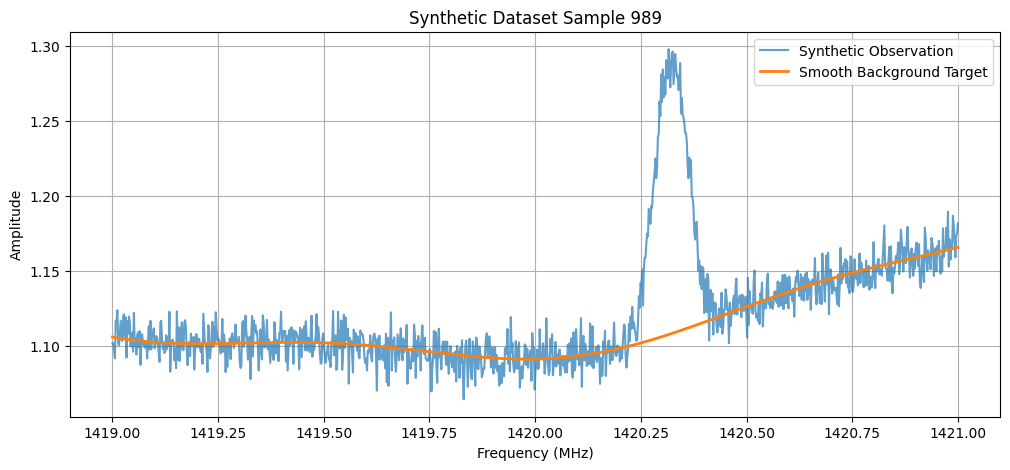

In [66]:
plt.plot(freq, X_raw[example_idx], label="Synthetic Observation", alpha=0.7)

plt.plot(freq, y_smooth[example_idx], label="Smooth Background Target", linewidth=2)

plt.title(f"Synthetic Dataset Sample {example_idx}")

plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Noise-Level Verification

The measured standard deviation of the generated noise is inspected across the dataset.

Because every observation is generated using the same nominal noise standard deviation but an independent random realization, the measured values should remain close to the configured noise level without being exactly identical.

In [67]:
print(
    "Configured noise standard deviation:",
    f"{NOISE_STD:.6f}"
)

print(
    "Mean measured noise standard deviation:",
    f"{np.mean(measured_noise_std):.6f}"
)

print(
    "Minimum measured noise standard deviation:",
    f"{np.min(measured_noise_std):.6f}"
)

print(
    "Maximum measured noise standard deviation:",
    f"{np.max(measured_noise_std):.6f}"
)

Configured noise standard deviation: 0.010000
Mean measured noise standard deviation: 0.009994
Minimum measured noise standard deviation: 0.009217
Maximum measured noise standard deviation: 0.010815


## Step 17 Summary

A reproducible multi-observation synthetic dataset was generated using the reusable signal pipeline.

The dataset contains 5000 independent synthetic observations together with their smooth background targets and spectral-line masks.

The generated arrays were verified for:

- consistent dimensions and data types,
- finite numerical values,
- binary spectral-line masks,
- the expected distribution of background distortion configurations,
- noise levels consistent with the configured generation process.

The dataset remains in its original amplitude scale and is now ready for dataset-level preprocessing and partitioning.

# Step 18 — Train, Validation, and Test Split

The generated synthetic dataset is now divided into independent training, validation, and test subsets before dataset-level preprocessing is applied.

A 70/15/15 partition is used:

- 70% training data,
- 15% validation data,
- 15% test data.

The split is stratified according to the generated background distortion type (`POLY`, `SIN`, or `BOTH`). This preserves approximately the same background-morphology distribution across all three subsets.

Dataset indices are split first and then used to partition every stored array. This guarantees that observations, targets, masks, and generation metadata remain correctly aligned.

## Split Configuration

A fixed random state is used to ensure that the same dataset partition can be reproduced in future notebook runs.

In [68]:
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

SPLIT_RANDOM_STATE = 42

assert np.isclose(
    TRAIN_SIZE + VALIDATION_SIZE + TEST_SIZE,
    1.0
)

print(f"Training fraction: {TRAIN_SIZE:.2f}")
print(f"Validation fraction: {VALIDATION_SIZE:.2f}")
print(f"Test fraction: {TEST_SIZE:.2f}")

Training fraction: 0.70
Validation fraction: 0.15
Test fraction: 0.15


## Dataset Index Split

The dataset indices are partitioned instead of splitting each array separately.

This approach prevents accidental misalignment between the synthetic observations and their corresponding targets, masks, and metadata.

The first split separates the training subset from the remaining data. The second split divides the remaining samples equally into validation and test subsets.

In [69]:
all_indices = np.arange(NUM_SAMPLES)

train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=(VALIDATION_SIZE + TEST_SIZE),
    random_state=SPLIT_RANDOM_STATE,
    stratify=distortion_types
)

In [70]:
validation_fraction_of_temp = (
    VALIDATION_SIZE
    / (VALIDATION_SIZE + TEST_SIZE)
)

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=(1 - validation_fraction_of_temp),
    random_state=SPLIT_RANDOM_STATE,
    stratify=distortion_types[temp_indices]
)

print(f"Training samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Test samples: {len(test_indices)}")

Training samples: 3500
Validation samples: 750
Test samples: 750


## Dataset Partitioning

The generated indices are now used to partition all dataset arrays.

The raw observations, smooth-background targets, spectral-line masks, distortion labels, noise statistics, and generation seeds remain aligned within each subset.

In [71]:
X_train_raw = X_raw[train_indices]
X_val_raw = X_raw[val_indices]
X_test_raw = X_raw[test_indices]

y_train_smooth = y_smooth[train_indices]
y_val_smooth = y_smooth[val_indices]
y_test_smooth = y_smooth[test_indices]

masks_train = masks[train_indices]
masks_val = masks[val_indices]
masks_test = masks[test_indices]

In [72]:
distortion_train = distortion_types[train_indices]
distortion_val = distortion_types[val_indices]
distortion_test = distortion_types[test_indices]

noise_std_train = measured_noise_std[train_indices]
noise_std_val = measured_noise_std[val_indices]
noise_std_test = measured_noise_std[test_indices]

seeds_train = sample_seeds[train_indices]
seeds_val = sample_seeds[val_indices]
seeds_test = sample_seeds[test_indices]

## Partition Shape Verification

The dimensions of the input, target, and mask arrays are checked to ensure that every subset contains the expected number of observations and spectral channels.

In [73]:
print("Training set")
print(f"  X: {X_train_raw.shape}")
print(f"  y: {y_train_smooth.shape}")
print(f"  masks: {masks_train.shape}")

print("\nValidation set")
print(f"  X: {X_val_raw.shape}")
print(f"  y: {y_val_smooth.shape}")
print(f"  masks: {masks_val.shape}")

print("\nTest set")
print(f"  X: {X_test_raw.shape}")
print(f"  y: {y_test_smooth.shape}")
print(f"  masks: {masks_test.shape}")

Training set
  X: (3500, 1024)
  y: (3500, 1024)
  masks: (3500, 1024)

Validation set
  X: (750, 1024)
  y: (750, 1024)
  masks: (750, 1024)

Test set
  X: (750, 1024)
  y: (750, 1024)
  masks: (750, 1024)


## Split Integrity Verification

The three index sets must be mutually exclusive.

This verification ensures that no synthetic observation appears in more than one dataset partition.

In [74]:
assert len(
    np.intersect1d(train_indices, val_indices)
) == 0

assert len(
    np.intersect1d(train_indices, test_indices)
) == 0

assert len(
    np.intersect1d(val_indices, test_indices)
) == 0

assert (
    len(train_indices)
    + len(val_indices)
    + len(test_indices)
    == NUM_SAMPLES
)

print("No overlap exists between dataset partitions.")
print("All generated samples are assigned exactly once.")

No overlap exists between dataset partitions.
All generated samples are assigned exactly once.


## Distortion Distribution Verification

The background distortion distribution is inspected independently in each subset.

Because stratified splitting was used, the proportions of `POLY`, `SIN`, and `BOTH` backgrounds should remain close to those of the complete synthetic dataset.

In [75]:
def print_distortion_distribution(labels, subset_name):
    unique_types, counts = np.unique(
        labels,
        return_counts=True
    )

    print(f"{subset_name} distortion distribution:")

    for distortion_type, count in zip(
        unique_types,
        counts
    ):
        percentage = (
            100 * count / len(labels)
        )

        print(
            f"  {distortion_type}: "
            f"{count} ({percentage:.2f}%)"
        )

In [76]:
print_distortion_distribution(
    distortion_train,
    "Training"
)

print()

print_distortion_distribution(
    distortion_val,
    "Validation"
)

print()

print_distortion_distribution(
    distortion_test,
    "Test"
)

Training distortion distribution:
  BOTH: 2464 (70.40%)
  POLY: 682 (19.49%)
  SIN: 354 (10.11%)

Validation distortion distribution:
  BOTH: 528 (70.40%)
  POLY: 146 (19.47%)
  SIN: 76 (10.13%)

Test distortion distribution:
  BOTH: 528 (70.40%)
  POLY: 146 (19.47%)
  SIN: 76 (10.13%)


## Random Partition Sample Verification

One observation from each partition is visualized together with its corresponding smooth-background target.

This provides a final qualitative check that the partitioning operation preserved the correct input-target correspondence.

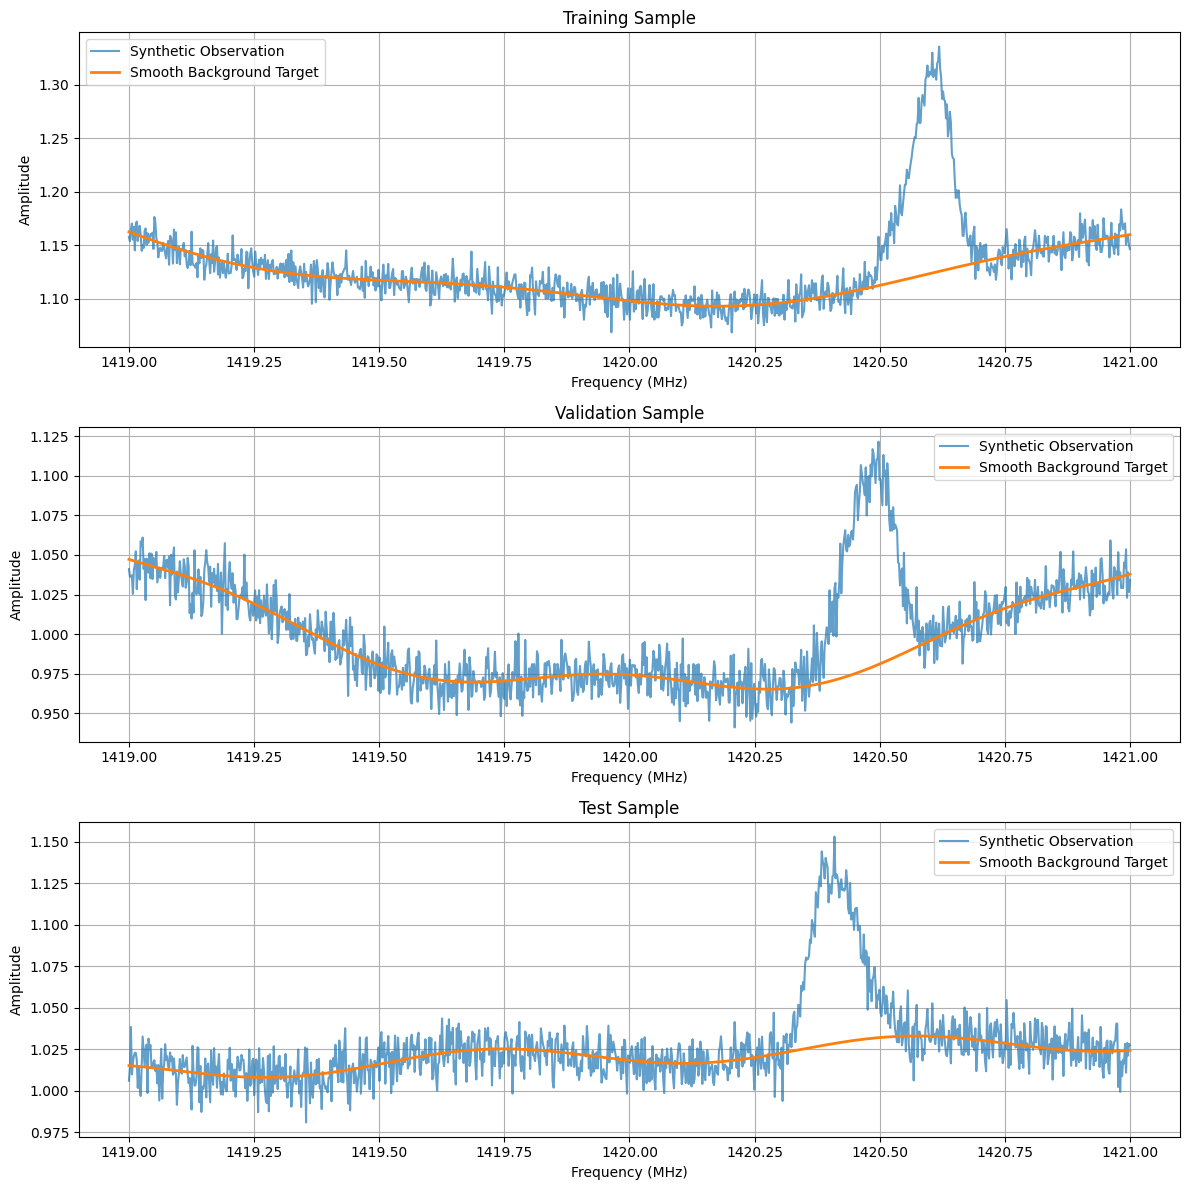

In [77]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

partition_data = [
    (
        X_train_raw,
        y_train_smooth,
        "Training Sample"
    ),
    (
        X_val_raw,
        y_val_smooth,
        "Validation Sample"
    ),
    (
        X_test_raw,
        y_test_smooth,
        "Test Sample"
    )
]

for ax, (X_subset, y_subset, title) in zip(
    axes,
    partition_data
):
    sample_idx = 0

    ax.plot(
        freq,
        X_subset[sample_idx],
        label="Synthetic Observation",
        alpha=0.7
    )

    ax.plot(
        freq,
        y_subset[sample_idx],
        label="Smooth Background Target",
        linewidth=2
    )

    ax.set_title(title)
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Amplitude")
    ax.legend()

plt.tight_layout()
plt.show()

## Step 18 Summary

The synthetic dataset was divided into independent training, validation, and test subsets using a 70/15/15 split.

Stratification by background distortion type preserved the approximate `POLY`, `SIN`, and `BOTH` morphology distribution across all partitions.

The dataset indices were split before partitioning the stored arrays, ensuring that observations, smooth-background targets, masks, and metadata remained correctly aligned.

Partition integrity checks confirmed that no sample appears in more than one subset and that every generated observation is assigned exactly once.

The three raw dataset partitions are now ready for preprocessing.

# Step 19 — Dataset-Level Signal Smoothing

The Savitzky–Golay preprocessing configuration validated on a single synthetic observation is now applied to the complete dataset.

The same filter parameters are used for the training, validation, and test partitions to maintain a consistent preprocessing pipeline across all observations.

Only the model inputs are filtered. The regression targets are preserved unchanged because they already represent the underlying smooth background before the addition of Gaussian noise and spectral-line structure.

The original raw partitions are also retained, allowing the raw and smoothed preprocessing branches to be compared during model development.

## Dataset Smoothing Configuration

The previously validated Savitzky–Golay configuration is reused without modification:

- window length: 31 spectral channels,
- polynomial order: 3.

Using the same fixed configuration across all dataset partitions ensures that differences between the raw and smoothed model branches originate from the preprocessing itself rather than from partition-specific filter settings.

In [78]:
print(f"Window length: {SAVGOL_WINDOW_LENGTH}")
print(f"Polynomial order: {SAVGOL_POLYORDER}")

assert SAVGOL_WINDOW_LENGTH % 2 == 1
assert SAVGOL_WINDOW_LENGTH > SAVGOL_POLYORDER
assert SAVGOL_WINDOW_LENGTH <= NUM_CHANNELS

print("Savitzky–Golay configuration is valid.")

Window length: 31
Polynomial order: 3
Savitzky–Golay configuration is valid.


## Training, Validation, and Test Smoothing

The Savitzky–Golay filter is applied independently along the spectral-channel axis of each observation.

The operation does not estimate any statistics from the dataset partitions. It applies the same fixed local filtering rule to every spectrum, so no information is transferred between training, validation, and test samples.

In [79]:
X_train_smoothed = savgol_filter(
    X_train_raw,
    window_length=SAVGOL_WINDOW_LENGTH,
    polyorder=SAVGOL_POLYORDER,
    axis=1
).astype(np.float32)

X_val_smoothed = savgol_filter(
    X_val_raw,
    window_length=SAVGOL_WINDOW_LENGTH,
    polyorder=SAVGOL_POLYORDER,
    axis=1
).astype(np.float32)

X_test_smoothed = savgol_filter(
    X_test_raw,
    window_length=SAVGOL_WINDOW_LENGTH,
    polyorder=SAVGOL_POLYORDER,
    axis=1
).astype(np.float32)

## Smoothed Dataset Verification

The smoothed partitions are checked to confirm that the filtering operation preserved the original dataset dimensions and produced valid numerical values.

The raw partitions remain unchanged and are retained as a separate preprocessing branch.

In [80]:
print("Training")
print(f"  Raw shape: {X_train_raw.shape}")
print(f"  Smoothed shape: {X_train_smoothed.shape}")

print("\nValidation")
print(f"  Raw shape: {X_val_raw.shape}")
print(f"  Smoothed shape: {X_val_smoothed.shape}")

print("\nTest")
print(f"  Raw shape: {X_test_raw.shape}")
print(f"  Smoothed shape: {X_test_smoothed.shape}")

Training
  Raw shape: (3500, 1024)
  Smoothed shape: (3500, 1024)

Validation
  Raw shape: (750, 1024)
  Smoothed shape: (750, 1024)

Test
  Raw shape: (750, 1024)
  Smoothed shape: (750, 1024)


In [81]:
assert X_train_smoothed.shape == X_train_raw.shape
assert X_val_smoothed.shape == X_val_raw.shape
assert X_test_smoothed.shape == X_test_raw.shape

assert np.all(np.isfinite(X_train_smoothed))
assert np.all(np.isfinite(X_val_smoothed))
assert np.all(np.isfinite(X_test_smoothed))

print("All smoothed dataset partitions are valid.")

All smoothed dataset partitions are valid.


## Dataset-Level Smoothing Comparison

A training observation is inspected before and after filtering to verify that the dataset-level implementation reproduces the behavior observed during the single-sample preprocessing experiment.

The corresponding smooth background target is included as a reference but is not modified by the smoothing operation.

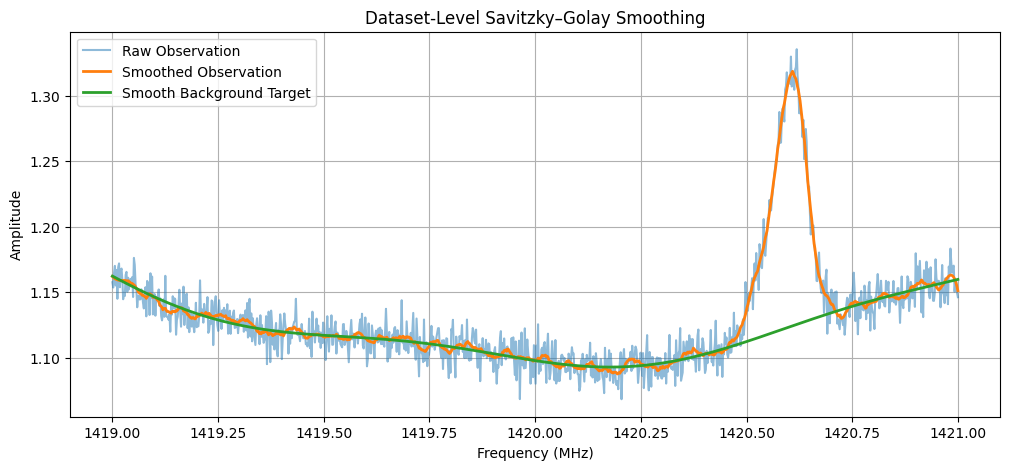

In [82]:
example_idx = 0

plt.plot(
    freq,
    X_train_raw[example_idx],
    label="Raw Observation",
    alpha=0.5
)

plt.plot(
    freq,
    X_train_smoothed[example_idx],
    label="Smoothed Observation",
    linewidth=2
)

plt.plot(
    freq,
    y_train_smooth[example_idx],
    label="Smooth Background Target",
    linewidth=2
)

plt.title("Dataset-Level Savitzky–Golay Smoothing")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Dataset-Level Smoothing Residual

The difference between the raw and smoothed training observation is inspected to verify the signal variation removed by the filter.

As in the single-sample analysis, this residual primarily reflects high-frequency fluctuations but is not interpreted as a pure noise estimate.

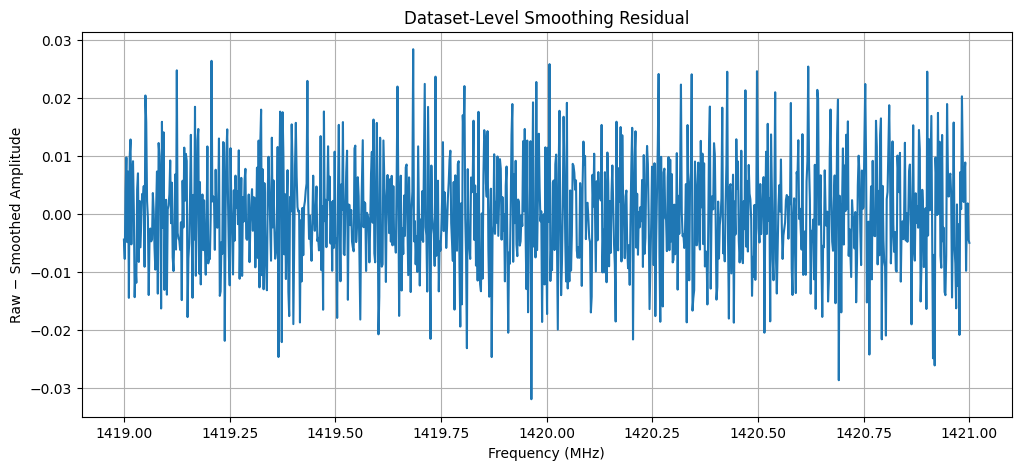

In [83]:
dataset_smoothing_residual = (
    X_train_raw[example_idx]
    - X_train_smoothed[example_idx]
)

plt.plot(
    freq,
    dataset_smoothing_residual
)

plt.title("Dataset-Level Smoothing Residual")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Raw − Smoothed Amplitude")

plt.show()

## Target Preservation Verification

The regression targets are intentionally left unchanged during smoothing.

This preserves the exact synthetic background generated before the addition of noise and spectral-line components and ensures that both preprocessing branches are trained against the same physical target.

In [84]:
print(f"Training target shape: {y_train_smooth.shape}")
print(f"Validation target shape: {y_val_smooth.shape}")
print(f"Test target shape: {y_test_smooth.shape}")

assert np.all(np.isfinite(y_train_smooth))
assert np.all(np.isfinite(y_val_smooth))
assert np.all(np.isfinite(y_test_smooth))

print("Smooth background targets remain unchanged and valid.")

Training target shape: (3500, 1024)
Validation target shape: (750, 1024)
Test target shape: (750, 1024)
Smooth background targets remain unchanged and valid.


## Step 19 Summary

The validated Savitzky–Golay filter was applied to every synthetic observation in the training, validation, and test partitions.

The same fixed filter configuration was used across all subsets, while the original raw observations were preserved as a separate model branch.

Only the input observations were filtered. The smooth background targets remained unchanged because they already represent the desired regression output.

The resulting raw and smoothed dataset branches are now ready for dataset-level standardization.

# Step 20 — Dataset-Level Z-Score Standardization

The raw and Savitzky–Golay preprocessing branches are now standardized across the complete dataset.

Each observation is standardized independently using its own mean and standard deviation. This preserves the relative spectral morphology of each synthetic observation while removing differences in absolute offset and scale.

The corresponding smooth-background target is transformed using the same mean and standard deviation as its input observation.

This ensures that each input–target pair remains in a common standardized coordinate system and that future model predictions can be transformed back to the original amplitude scale.

## Dataset Standardization Function

A vectorized standardization function is defined for two-dimensional spectral datasets.

The function calculates one mean and one standard deviation per observation along the spectral-channel axis.

The calculated statistics are returned together with the standardized dataset because they will later be required for target transformation and inverse scaling of model predictions.

In [85]:
def standardize_dataset(
    data,
    epsilon=STANDARDIZATION_EPSILON
):
    """
    Apply per-observation Z-score standardization to a spectral dataset.

    Parameters
    ----------
    data : np.ndarray
        Two-dimensional array with shape (samples, channels).
    epsilon : float
        Minimum allowed standard deviation.

    Returns
    -------
    standardized_data : np.ndarray
        Standardized dataset.
    sample_means : np.ndarray
        Mean of each observation.
    sample_stds : np.ndarray
        Standard deviation of each observation.
    """
    data = np.asarray(data, dtype=np.float32)

    if data.ndim != 2:
        raise ValueError(
            "The dataset must have shape (samples, channels)."
        )

    sample_means = np.mean(
        data,
        axis=1,
        keepdims=True
    )

    sample_stds = np.std(
        data,
        axis=1,
        keepdims=True
    )

    if np.any(sample_stds < epsilon):
        raise ValueError(
            "At least one observation has a standard deviation "
            "too small for Z-score standardization."
        )

    standardized_data = (
        data - sample_means
    ) / sample_stds

    return (
        standardized_data.astype(np.float32),
        sample_means.astype(np.float32),
        sample_stds.astype(np.float32)
    )

## Raw Observation Standardization

The raw training, validation, and test observations are standardized independently.

The resulting means and standard deviations are stored for every observation so that the corresponding smooth-background targets can be transformed using exactly the same parameters.

In [86]:
(X_train_raw_std, raw_train_means, raw_train_stds) = standardize_dataset(X_train_raw)

(X_val_raw_std, raw_val_means, raw_val_stds) = standardize_dataset(X_val_raw)

(X_test_raw_std, raw_test_means, raw_test_stds) = standardize_dataset(X_test_raw)

## Smoothed Observation Standardization

The same per-observation transformation is applied to the Savitzky–Golay preprocessing branch.

Raw and smoothed observations remain separate model inputs while sharing the same underlying smooth-background targets.

In [87]:
(X_train_smoothed_std, smoothed_train_means, smoothed_train_stds) = standardize_dataset(X_train_smoothed)

(X_val_smoothed_std, smoothed_val_means, smoothed_val_stds) = standardize_dataset(X_val_smoothed)

(X_test_smoothed_std, smoothed_test_means, smoothed_test_stds) = standardize_dataset(X_test_smoothed)

## Background Target Standardization

The smooth-background targets are not standardized using independent target statistics.

Instead, each target is transformed using the mean and standard deviation calculated from its corresponding input observation.

This keeps the model input and regression target in the same numerical reference frame and allows predicted standardized backgrounds to be accurately restored to their original amplitude scale.

In [88]:
y_train_raw_std = (
    y_train_smooth - raw_train_means
) / raw_train_stds

y_val_raw_std = (
    y_val_smooth - raw_val_means
) / raw_val_stds

y_test_raw_std = (
    y_test_smooth - raw_test_means
) / raw_test_stds

y_train_raw_std = y_train_raw_std.astype(np.float32)
y_val_raw_std = y_val_raw_std.astype(np.float32)
y_test_raw_std = y_test_raw_std.astype(np.float32)

In [89]:
y_train_smoothed_std = (
    y_train_smooth - smoothed_train_means
) / smoothed_train_stds

y_val_smoothed_std = (
    y_val_smooth - smoothed_val_means
) / smoothed_val_stds

y_test_smoothed_std = (
    y_test_smooth - smoothed_test_means
) / smoothed_test_stds

y_train_smoothed_std = y_train_smoothed_std.astype(np.float32)
y_val_smoothed_std = y_val_smoothed_std.astype(np.float32)
y_test_smoothed_std = y_test_smoothed_std.astype(np.float32)

## Standardization Verification

The standardized input datasets are checked for approximately zero mean and unit standard deviation on a per-observation basis.

Small deviations from the exact theoretical values may occur because the arrays are stored using `float32` precision.

In [90]:
raw_train_means_check = np.mean(
    X_train_raw_std,
    axis=1
)

raw_train_stds_check = np.std(
    X_train_raw_std,
    axis=1
)

smoothed_train_means_check = np.mean(
    X_train_smoothed_std,
    axis=1
)

smoothed_train_stds_check = np.std(
    X_train_smoothed_std,
    axis=1
)

print(
    "Maximum absolute raw mean:",
    f"{np.max(np.abs(raw_train_means_check)):.8f}"
)

print(
    "Maximum raw std deviation from 1:",
    f"{np.max(np.abs(raw_train_stds_check - 1.0)):.8f}"
)

print(
    "Maximum absolute smoothed mean:",
    f"{np.max(np.abs(smoothed_train_means_check)):.8f}"
)

print(
    "Maximum smoothed std deviation from 1:",
    f"{np.max(np.abs(smoothed_train_stds_check - 1.0)):.8f}"
)

Maximum absolute raw mean: 0.00001001
Maximum raw std deviation from 1: 0.00000018
Maximum absolute smoothed mean: 0.00001352
Maximum smoothed std deviation from 1: 0.00000018


In [91]:
assert np.all(np.isfinite(X_train_raw_std))
assert np.all(np.isfinite(X_val_raw_std))
assert np.all(np.isfinite(X_test_raw_std))

assert np.all(np.isfinite(X_train_smoothed_std))
assert np.all(np.isfinite(X_val_smoothed_std))
assert np.all(np.isfinite(X_test_smoothed_std))

assert np.all(np.isfinite(y_train_raw_std))
assert np.all(np.isfinite(y_val_raw_std))
assert np.all(np.isfinite(y_test_raw_std))

assert np.all(np.isfinite(y_train_smoothed_std))
assert np.all(np.isfinite(y_val_smoothed_std))
assert np.all(np.isfinite(y_test_smoothed_std))

print("All standardized input and target arrays are valid.")

All standardized input and target arrays are valid.


## Standardized Input–Target Verification

A standardized training observation is compared with its corresponding standardized smooth-background target.

The input retains the noise and spectral-line structure, while the target represents the underlying background transformed using the same input statistics.

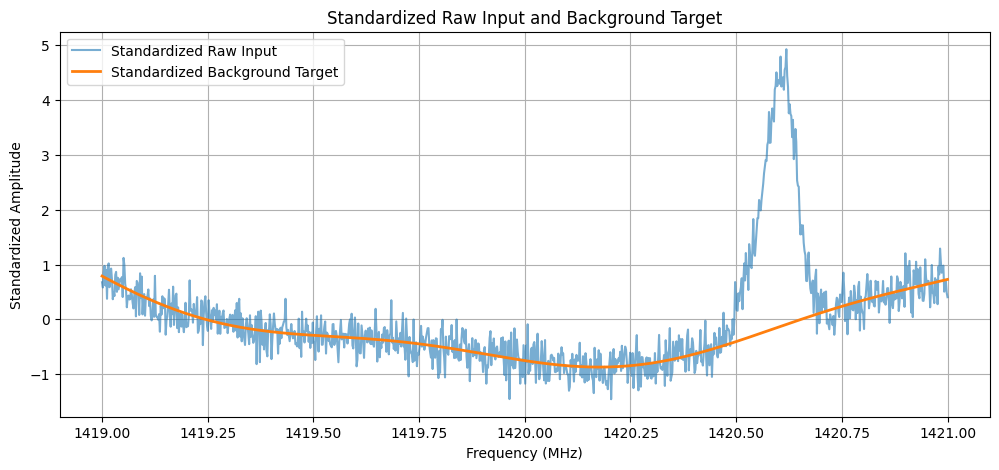

In [92]:
example_idx = 0

plt.plot(
    freq,
    X_train_raw_std[example_idx],
    label="Standardized Raw Input",
    alpha=0.6
)

plt.plot(
    freq,
    y_train_raw_std[example_idx],
    label="Standardized Background Target",
    linewidth=2
)

plt.title("Standardized Raw Input and Background Target")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Standardized Amplitude")
plt.legend()

plt.show()

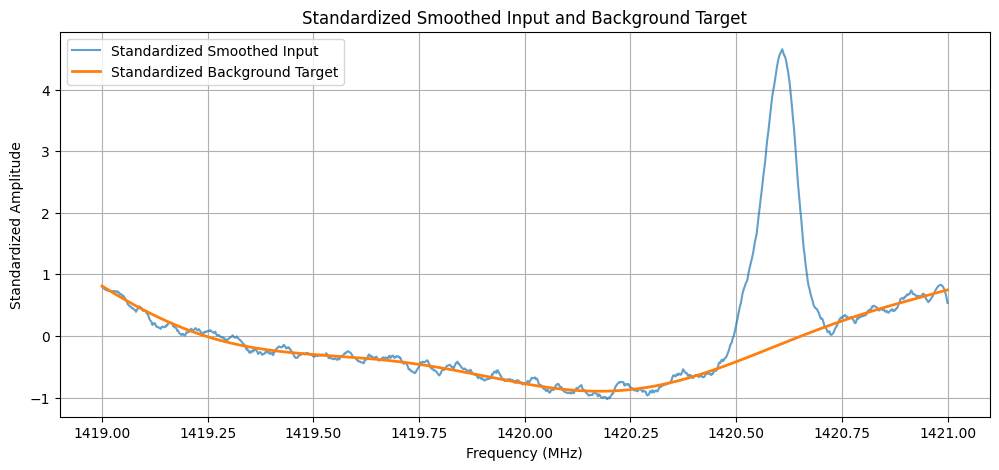

In [93]:
plt.plot(
    freq,
    X_train_smoothed_std[example_idx],
    label="Standardized Smoothed Input",
    alpha=0.7
)

plt.plot(
    freq,
    y_train_smoothed_std[example_idx],
    label="Standardized Background Target",
    linewidth=2
)

plt.title("Standardized Smoothed Input and Background Target")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Standardized Amplitude")
plt.legend()

plt.show()

## Target Inverse-Transformation Verification

A standardized background target is transformed back to the original amplitude scale using the input statistics stored for the same observation.

The reconstructed signal should match the original smooth-background target within floating-point precision.

In [94]:
reconstructed_target = (
    y_train_smoothed_std[example_idx]
    * smoothed_train_stds[example_idx]
    + smoothed_train_means[example_idx]
)

target_reconstruction_error = np.max(
    np.abs(
        reconstructed_target
        - y_train_smooth[example_idx]
    )
)

print(
    "Maximum target reconstruction error:",
    f"{target_reconstruction_error:.10f}"
)

Maximum target reconstruction error: 0.0000000000


## Step 20 Summary

Per-observation Z-score standardization was applied independently to the raw and Savitzky–Golay dataset branches.

For each observation, the mean and standard deviation were retained and used to transform the corresponding smooth-background target into the same numerical reference frame.

The standardized inputs were verified to have approximately zero mean and unit standard deviation, while all input and target arrays were checked for valid finite values.

An inverse-transformation test confirmed that the standardized regression targets can be accurately restored to their original amplitude scale.

The raw and smoothed standardized dataset branches are now prepared for TensorFlow model input formatting and subsequent neural network development.

# Step 21 — TensorFlow Input Shape Preparation

The standardized dataset branches are now prepared for TensorFlow model development.

The current spectral arrays have the shape:

(samples, spectral channels)

A one-dimensional convolutional network expects an additional feature-channel dimension:

(samples, spectral channels, features)

Because each observation contains a single amplitude value per frequency channel, one feature channel is added to every input and target array.

Both the raw and Savitzky–Golay preprocessing branches are preserved so that they can later be evaluated using the same neural network architecture.

## Raw Branch Reshaping

The standardized raw inputs and their corresponding background targets are reshaped by adding a final singleton channel dimension.

No numerical values are modified during this operation.

In [95]:
X_train_raw_nn = X_train_raw_std[..., np.newaxis]
X_val_raw_nn = X_val_raw_std[..., np.newaxis]
X_test_raw_nn = X_test_raw_std[..., np.newaxis]

y_train_raw_nn = y_train_raw_std[..., np.newaxis]
y_val_raw_nn = y_val_raw_std[..., np.newaxis]
y_test_raw_nn = y_test_raw_std[..., np.newaxis]

## Smoothed Branch Reshaping

The same transformation is applied to the standardized Savitzky–Golay branch.

The resulting arrays have the same dimensions as the raw branch, allowing both preprocessing approaches to be evaluated under identical model conditions.

In [96]:
X_train_smoothed_nn = X_train_smoothed_std[..., np.newaxis]
X_val_smoothed_nn = X_val_smoothed_std[..., np.newaxis]
X_test_smoothed_nn = X_test_smoothed_std[..., np.newaxis]

y_train_smoothed_nn = y_train_smoothed_std[..., np.newaxis]
y_val_smoothed_nn = y_val_smoothed_std[..., np.newaxis]
y_test_smoothed_nn = y_test_smoothed_std[..., np.newaxis]

## TensorFlow Shape Verification

The reshaped arrays are inspected before model construction.

Every input and target should now contain:

- the number of observations,
- 1024 spectral channels,
- one amplitude feature per channel.

Input and target dimensions must remain identical because the network will perform channel-by-channel background regression.

In [97]:
print("Raw branch")
print(f"  X_train: {X_train_raw_nn.shape}")
print(f"  y_train: {y_train_raw_nn.shape}")
print(f"  X_val:   {X_val_raw_nn.shape}")
print(f"  y_val:   {y_val_raw_nn.shape}")
print(f"  X_test:  {X_test_raw_nn.shape}")
print(f"  y_test:  {y_test_raw_nn.shape}")

print("\nSmoothed branch")
print(f"  X_train: {X_train_smoothed_nn.shape}")
print(f"  y_train: {y_train_smoothed_nn.shape}")
print(f"  X_val:   {X_val_smoothed_nn.shape}")
print(f"  y_val:   {y_val_smoothed_nn.shape}")
print(f"  X_test:  {X_test_smoothed_nn.shape}")
print(f"  y_test:  {y_test_smoothed_nn.shape}")

Raw branch
  X_train: (3500, 1024, 1)
  y_train: (3500, 1024, 1)
  X_val:   (750, 1024, 1)
  y_val:   (750, 1024, 1)
  X_test:  (750, 1024, 1)
  y_test:  (750, 1024, 1)

Smoothed branch
  X_train: (3500, 1024, 1)
  y_train: (3500, 1024, 1)
  X_val:   (750, 1024, 1)
  y_val:   (750, 1024, 1)
  X_test:  (750, 1024, 1)
  y_test:  (750, 1024, 1)


## TensorFlow Array Validation

The neural network arrays are checked for matching dimensions, `float32` precision, and finite numerical values before they are passed to TensorFlow.

In [98]:
assert X_train_raw_nn.shape == y_train_raw_nn.shape
assert X_val_raw_nn.shape == y_val_raw_nn.shape
assert X_test_raw_nn.shape == y_test_raw_nn.shape

assert X_train_smoothed_nn.shape == y_train_smoothed_nn.shape
assert X_val_smoothed_nn.shape == y_val_smoothed_nn.shape
assert X_test_smoothed_nn.shape == y_test_smoothed_nn.shape

assert X_train_raw_nn.dtype == np.float32
assert X_train_smoothed_nn.dtype == np.float32

assert np.all(np.isfinite(X_train_raw_nn))
assert np.all(np.isfinite(y_train_raw_nn))

assert np.all(np.isfinite(X_train_smoothed_nn))
assert np.all(np.isfinite(y_train_smoothed_nn))

print("All neural network arrays are valid.")

All neural network arrays are valid.


## Step 21 Summary

The standardized raw and Savitzky–Golay dataset branches were reshaped for one-dimensional convolutional neural network input.

A single feature-channel dimension was added to every observation and background target, producing arrays with the structure:

(samples, spectral channels, 1)

The reshaped arrays were verified for matching dimensions, `float32` precision, and finite numerical values.

Both preprocessing branches are now ready for TensorFlow dataset construction and neural network training.

# Step 22 — TensorFlow Dataset Pipeline

The preprocessed NumPy arrays are now converted into TensorFlow datasets for model training and evaluation.

Separate dataset pipelines are created for the raw and Savitzky–Golay preprocessing branches while preserving the same train, validation, and test partitions.

The training datasets are shuffled before batching to vary the sample order between epochs. Validation and test datasets remain unshuffled to preserve deterministic evaluation.

Batching and prefetching are applied to improve training efficiency without modifying the underlying observations or regression targets.

## Dataset Pipeline Configuration

A batch size of 32 is used as the initial training configuration.

The full training-set size is used as the shuffle buffer so that all training observations can participate in the random ordering process.

TensorFlow's automatic prefetching is enabled to overlap data preparation with model execution.

In [99]:
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = len(X_train_raw_nn)

TF_DATA_SEED = 42

print(f"Batch size: {BATCH_SIZE}")
print(f"Shuffle buffer size: {SHUFFLE_BUFFER_SIZE}")
print(f"TensorFlow dataset seed: {TF_DATA_SEED}")

Batch size: 32
Shuffle buffer size: 3500
TensorFlow dataset seed: 42


## Raw TensorFlow Dataset Branch

The standardized raw observations and their corresponding standardized background targets are converted into TensorFlow datasets.

Only the training dataset is shuffled. Validation and test datasets retain their original order.

In [100]:
train_raw_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_raw_nn, y_train_raw_nn)
)

val_raw_ds = tf.data.Dataset.from_tensor_slices(
    (X_val_raw_nn, y_val_raw_nn)
)

test_raw_ds = tf.data.Dataset.from_tensor_slices(
    (X_test_raw_nn, y_test_raw_nn)
)

In [101]:
train_raw_ds = (
    train_raw_ds
    .shuffle(
        buffer_size=SHUFFLE_BUFFER_SIZE,
        seed=TF_DATA_SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_raw_ds = (
    val_raw_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_raw_ds = (
    test_raw_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

## Smoothed TensorFlow Dataset Branch

The same TensorFlow pipeline is applied to the standardized Savitzky–Golay observations.

Using identical batching and data-loading settings ensures that future comparisons between the raw and smoothed branches are based on the preprocessing difference rather than different training pipelines.

In [102]:
train_smoothed_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_train_smoothed_nn,
        y_train_smoothed_nn
    )
)

val_smoothed_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_val_smoothed_nn,
        y_val_smoothed_nn
    )
)

test_smoothed_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_test_smoothed_nn,
        y_test_smoothed_nn
    )
)

In [103]:
train_smoothed_ds = (
    train_smoothed_ds
    .shuffle(
        buffer_size=SHUFFLE_BUFFER_SIZE,
        seed=TF_DATA_SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_smoothed_ds = (
    val_smoothed_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_smoothed_ds = (
    test_smoothed_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

## Dataset Structure Verification

The TensorFlow dataset specifications are inspected before model construction.

Each batch should contain three dimensions:

- batch size,
- 1024 spectral channels,
- one amplitude feature.

The input and target tensors must have identical shapes because the network will predict one background value for every spectral channel.

In [104]:
print("Raw training dataset:")
print(train_raw_ds.element_spec)

print("\nSmoothed training dataset:")
print(train_smoothed_ds.element_spec)

Raw training dataset:
(TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None))

Smoothed training dataset:
(TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None))


## Batch Verification

One batch from each preprocessing branch is inspected to verify the dimensions and numerical validity of the tensors supplied to the neural network.

In [105]:
raw_input_batch, raw_target_batch = next(
    iter(train_raw_ds)
)

smoothed_input_batch, smoothed_target_batch = next(
    iter(train_smoothed_ds)
)

print("Raw branch")
print(f"  Input batch shape: {raw_input_batch.shape}")
print(f"  Target batch shape: {raw_target_batch.shape}")

print("\nSmoothed branch")
print(
    f"  Input batch shape: "
    f"{smoothed_input_batch.shape}"
)
print(
    f"  Target batch shape: "
    f"{smoothed_target_batch.shape}"
)

Raw branch
  Input batch shape: (32, 1024, 1)
  Target batch shape: (32, 1024, 1)

Smoothed branch
  Input batch shape: (32, 1024, 1)
  Target batch shape: (32, 1024, 1)


In [106]:
assert tf.reduce_all(
    tf.math.is_finite(raw_input_batch)
)

assert tf.reduce_all(
    tf.math.is_finite(raw_target_batch)
)

assert tf.reduce_all(
    tf.math.is_finite(smoothed_input_batch)
)

assert tf.reduce_all(
    tf.math.is_finite(smoothed_target_batch)
)

print("All inspected TensorFlow batches are valid.")

All inspected TensorFlow batches are valid.


## Dataset Batch Count Verification

The expected number of batches is verified for each partition.

Because incomplete final batches are retained, the number of batches is determined by the ceiling of the number of observations divided by the batch size.

In [107]:
expected_train_batches = int(
    np.ceil(len(X_train_raw_nn) / BATCH_SIZE)
)

expected_val_batches = int(
    np.ceil(len(X_val_raw_nn) / BATCH_SIZE)
)

expected_test_batches = int(
    np.ceil(len(X_test_raw_nn) / BATCH_SIZE)
)

print(
    f"Expected training batches: "
    f"{expected_train_batches}"
)

print(
    f"Expected validation batches: "
    f"{expected_val_batches}"
)

print(
    f"Expected test batches: "
    f"{expected_test_batches}"
)

Expected training batches: 110
Expected validation batches: 24
Expected test batches: 24


## Step 22 Summary

TensorFlow dataset pipelines were created for both the raw and Savitzky–Golay preprocessing branches.

Training observations are shuffled using a fixed seed and then grouped into batches of 32 samples. Validation and test observations remain unshuffled for deterministic evaluation.

All datasets use automatic prefetching to improve training efficiency.

The dataset specifications and sample batches were verified for the expected `(batch, 1024, 1)` structure, `float32` precision, and finite numerical values.

Both preprocessing branches are now ready for the first background-estimation neural network.

# Step 23 — Baseline 1D CNN for Background Estimation

A fully convolutional one-dimensional neural network is used as the initial baseline for synthetic background estimation.

The network receives a complete standardized spectrum and predicts one background amplitude for every spectral channel.

The architecture preserves the original spectral resolution throughout the network. No pooling or flattening operations are used because the regression output must remain aligned channel-by-channel with the input spectrum.

Several convolutional layers progressively extract local spectral structure, while the final linear convolution produces the estimated background profile.

The same architecture will be used for both the raw and Savitzky–Golay preprocessing branches to ensure a direct comparison between preprocessing strategies.

## Baseline Model Architecture

The baseline network uses progressively deeper one-dimensional convolutional layers with `same` padding.

`same` padding preserves the 1024-channel spectral dimension after every convolution.

ReLU activation is used in the hidden layers, while the output layer uses a linear activation because background estimation is a continuous regression problem.

In [108]:
def build_baseline_1d_cnn(input_shape):
    """
    Build a fully convolutional 1D regression model for
    channel-wise background estimation.

    Parameters
    ----------
    input_shape : tuple
        Shape of one spectral observation.

    Returns
    -------
    tf.keras.Model
        Compiled-ready baseline 1D CNN.
    """
    inputs = tf.keras.Input(
        shape=input_shape,
        name="spectrum_input"
    )

    x = layers.Conv1D(
        filters=32,
        kernel_size=9,
        padding="same",
        activation="relu",
        name="conv_1"
    )(inputs)

    x = layers.Conv1D(
        filters=64,
        kernel_size=7,
        padding="same",
        activation="relu",
        name="conv_2"
    )(x)

    x = layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding="same",
        activation="relu",
        name="conv_3"
    )(x)

    x = layers.Conv1D(
        filters=32,
        kernel_size=5,
        padding="same",
        activation="relu",
        name="conv_4"
    )(x)

    outputs = layers.Conv1D(
        filters=1,
        kernel_size=1,
        padding="same",
        activation="linear",
        name="background_output"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="baseline_1d_cnn"
    )

    return model

## Model Compilation

The baseline model is trained as a regression network.

Mean Squared Error is used as the optimization loss because the objective is to minimize the point-by-point difference between the predicted and true background profiles.

Mean Absolute Error and Root Mean Squared Error are included as additional training metrics for easier interpretation of model performance.

In [109]:
LEARNING_RATE = 1e-3

baseline_model = build_baseline_1d_cnn(
    input_shape=(NUM_CHANNELS, 1)
)

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),
        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

## Model Architecture Verification

The model summary is inspected to verify that the spectral dimension remains unchanged throughout the network.

The expected output shape is `(None, 1024, 1)`, matching the dimensions of the standardized background targets.

In [110]:
baseline_model.summary()

Model: "baseline_1d_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectrum_input (InputLayer)     │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv1D)                 │ (None, 1024, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv1D)                 │ (None, 1024, 64)       │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv1D)                 │ (None, 1024, 64)       │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv1D)                 │ (None, 1024, 32)       │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ background_output (Conv1D)      │ (None, 1024, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,569 (178.00 KB)

 Trainable params: 45,569 (178.00 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
expected_output_shape = (
    None,
    NUM_CHANNELS,
    1
)

assert baseline_model.output_shape == expected_output_shape

print(
    "Model output shape:",
    baseline_model.output_shape
)

print(
    "Trainable parameters:",
    baseline_model.count_params()
)

print("Baseline model architecture is valid.")

Model output shape: (None, 1024, 1)
Trainable parameters: 45569
Baseline model architecture is valid.


## Independent Raw and Smoothed Models

Two independent model instances are created from the same architecture.

Using separate models prevents the training of one preprocessing branch from affecting the weights of the other branch.

Both models therefore begin with the same architecture and training configuration but learn independently from the raw and smoothed datasets.

In [112]:
raw_baseline_model = build_baseline_1d_cnn(
    input_shape=(NUM_CHANNELS, 1)
)

smoothed_baseline_model = build_baseline_1d_cnn(
    input_shape=(NUM_CHANNELS, 1)
)

In [113]:
def compile_baseline_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            ),
            tf.keras.metrics.RootMeanSquaredError(
                name="rmse"
            )
        ]
    )


compile_baseline_model(raw_baseline_model)
compile_baseline_model(smoothed_baseline_model)

print("Raw baseline model compiled.")
print("Smoothed baseline model compiled.")

Raw baseline model compiled.
Smoothed baseline model compiled.


## Step 23 Summary

A fully convolutional 1D CNN was implemented as the initial background-estimation baseline.

The architecture preserves the complete 1024-channel spectral resolution and produces one continuous background prediction per input channel.

The model uses four hidden convolutional layers followed by a linear single-channel output layer.

Mean Squared Error was selected as the optimization loss, while MAE and RMSE were added as training metrics.

Independent but architecturally identical models were created for the raw and Savitzky–Golay preprocessing branches, enabling a controlled comparison between the two preprocessing strategies.

# Step 24 — Training Configuration and Callbacks

The baseline training procedure is configured before fitting either preprocessing branch.

Both the raw and Savitzky–Golay models will use the same training configuration so that their performance can be compared under identical optimization conditions.

The training setup includes:

- a maximum number of training epochs,
- early stopping based on validation loss,
- adaptive learning-rate reduction when validation performance stops improving,
- restoration of the best model weights observed during training.

These controls reduce unnecessary training while preserving the best validation-stage model state.

## Training Hyperparameters

A maximum of 100 epochs is used for the initial baseline experiment.

Training may stop earlier if the validation loss stops improving.

The batch size is inherited from the TensorFlow dataset pipeline created previously.

In [114]:
MAX_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 12
LR_REDUCTION_PATIENCE = 5
LR_REDUCTION_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6

print(f"Maximum epochs: {MAX_EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Learning-rate reduction patience: {LR_REDUCTION_PATIENCE}")
print(f"Learning-rate reduction factor: {LR_REDUCTION_FACTOR}")
print(f"Minimum learning rate: {MIN_LEARNING_RATE}")

Maximum epochs: 100
Early stopping patience: 12
Learning-rate reduction patience: 5
Learning-rate reduction factor: 0.5
Minimum learning rate: 1e-06


## Early Stopping

Early stopping monitors the validation loss during training.

If the validation loss does not improve for a predefined number of consecutive epochs, training is terminated.

The model weights corresponding to the best observed validation loss are restored automatically.

In [115]:
def create_early_stopping():
    return tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

## Learning-Rate Reduction

The learning rate is reduced when the validation loss reaches a plateau.

This allows the optimizer to make smaller parameter updates during the later stages of training without changing the original optimizer configuration manually.

In [116]:
def create_lr_scheduler():
    return tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=LR_REDUCTION_FACTOR,
        patience=LR_REDUCTION_PATIENCE,
        min_lr=MIN_LEARNING_RATE,
        verbose=1
    )

## Callback Factory

A new callback set is created for every training run.

This ensures that the raw and smoothed model experiments maintain independent callback states while using identical training rules.

In [117]:
def create_training_callbacks():
    return [
        create_early_stopping(),
        create_lr_scheduler()
    ]

## Training Configuration Verification

The callback configuration is inspected before model fitting to verify that both training controls are initialized correctly.

In [118]:
test_callbacks = create_training_callbacks()

for callback in test_callbacks:
    print(type(callback).__name__)

EarlyStopping
ReduceLROnPlateau


## Fair Branch Comparison

The raw and Savitzky–Golay preprocessing branches will be trained using:

- the same 1D CNN architecture,
- the same optimizer and initial learning rate,
- the same maximum number of epochs,
- the same callback configuration,
- the same dataset split,
- the same batch size.

This isolates preprocessing as the main experimental difference between the two baseline models.

In [119]:
print("Raw model learning rate:")
print(
    float(
        tf.keras.backend.get_value(
            raw_baseline_model.optimizer.learning_rate
        )
    )
)

print("\nSmoothed model learning rate:")
print(
    float(
        tf.keras.backend.get_value(
            smoothed_baseline_model.optimizer.learning_rate
        )
    )
)

Raw model learning rate:
0.0010000000474974513

Smoothed model learning rate:
0.0010000000474974513


## Step 24 Summary

The baseline training procedure was configured for both preprocessing branches.

A maximum of 100 epochs was defined together with early stopping and adaptive learning-rate reduction based on validation loss.

The best validation-stage weights will be restored automatically when training ends.

Independent callback instances will be created for each model while keeping all training hyperparameters identical.

The raw and Savitzky–Golay baseline models are now ready for controlled training.

# Step 25 — Raw Baseline Model Training

The first baseline experiment trains the 1D CNN using the standardized raw observations.

This branch retains the original Gaussian noise and spectral-line structure generated in the synthetic observations. The model is trained to reconstruct the corresponding standardized smooth background profile.

Before training begins, the initial model weights are preserved. The same initialization will later be assigned to the Savitzky–Golay model so that the preprocessing comparison is not influenced by different random weight initialization.

Training performance is monitored using validation loss, MAE, and RMSE.

## Initial Weight Preservation

The initial weights of the raw baseline model are stored before optimization begins.

These weights will be reused in the smoothed preprocessing experiment to ensure that both models start from the same parameter values.

In [120]:
initial_baseline_weights = [
    weight.copy()
    for weight in raw_baseline_model.get_weights()
]

print(
    f"Stored {len(initial_baseline_weights)} "
    "initial weight arrays."
)

Stored 10 initial weight arrays.


## Raw Baseline Training

The raw baseline model is trained using the TensorFlow dataset pipeline prepared previously.

Validation performance is evaluated after every epoch.

Early stopping and learning-rate reduction are controlled by newly created callback instances so that the training state remains independent from future experiments.

In [121]:
raw_history = raw_baseline_model.fit(
    train_raw_ds,
    validation_data=val_raw_ds,
    epochs=MAX_EPOCHS,
    callbacks=create_training_callbacks(),
    verbose=1
)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 0.0976 - mae: 0.1790 - rmse: 0.3123 - val_loss: 0.0576 - val_mae: 0.1328 - val_rmse: 0.2401 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0534 - mae: 0.1302 - rmse: 0.2311 - val_loss: 0.0462 - val_mae: 0.1211 - val_rmse: 0.2149 - learning_rate: 0.0010
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0466 - mae: 0.1210 - rmse: 0.2160 - val_loss: 0.0460 - val_mae: 0.1149 - val_rmse: 0.2144 - learning_rate: 0.0010
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0442 - mae: 0.1184 - rmse: 0.2101 - val_loss: 0.0416 - val_mae: 0.1156 - val_rmse: 0.2040 - learning_rate: 0.0010
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0436 - mae: 0.1166 - rmse: 0.2088 - val_loss: 0.0409 - val_mae: 0.1112 - val_rmse: 0.2022 - learning_rate: 0.0010
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0415 - mae: 0.1135 - rmse: 0.2037 - val_loss:

## Training Run Summary

The training history is inspected to determine:

- the number of completed epochs,
- the epoch with the lowest validation loss,
- the corresponding validation MSE,
- the final restored model state.

Because early stopping restores the best weights, the final model parameters do not necessarily correspond to the last recorded epoch.

In [122]:
raw_epochs_trained = len(
    raw_history.history["loss"]
)

raw_best_epoch = (
    np.argmin(
        raw_history.history["val_loss"]
    )
    + 1
)

raw_best_val_loss = np.min(
    raw_history.history["val_loss"]
)

print(
    f"Completed epochs: {raw_epochs_trained}"
)

print(
    f"Best validation epoch: {raw_best_epoch}"
)

print(
    "Best validation MSE:",
    f"{raw_best_val_loss:.6f}"
)

Completed epochs: 61
Best validation epoch: 49
Best validation MSE: 0.036032


## Training and Validation Loss

The Mean Squared Error curves are compared across epochs.

A decreasing training and validation loss indicates that the network is learning the underlying background mapping.

A persistent separation between the two curves may indicate overfitting, while a plateau in both curves suggests that further training provides limited improvement.

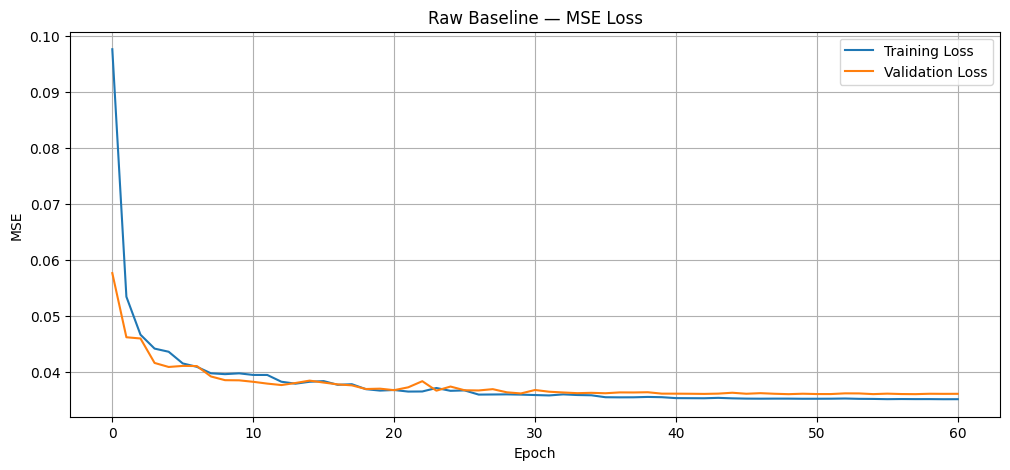

In [123]:
plt.plot(
    raw_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    raw_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Raw Baseline — MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.show()

## Mean Absolute Error

The MAE history provides an additional measure of the average channel-wise difference between the predicted and target standardized backgrounds.

Unlike MSE, MAE does not square large deviations and therefore provides a complementary view of regression performance.

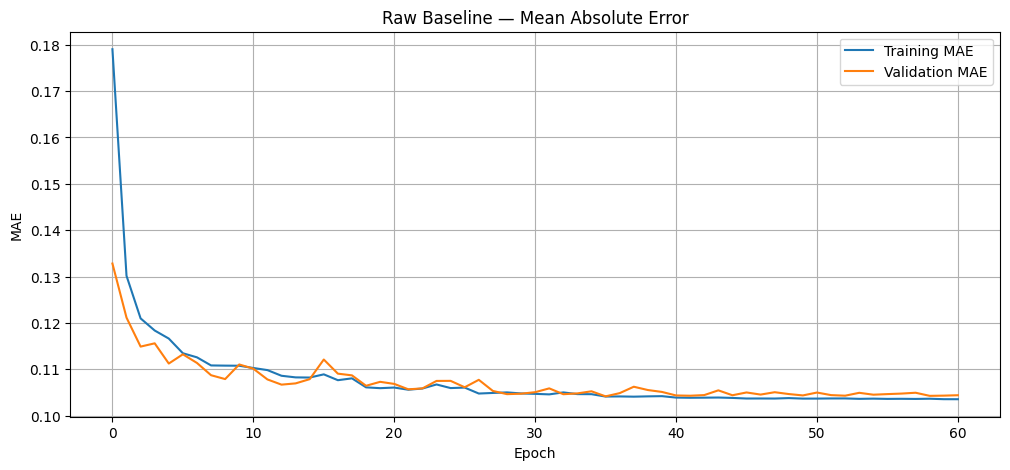

In [124]:
plt.plot(
    raw_history.history["mae"],
    label="Training MAE"
)

plt.plot(
    raw_history.history["val_mae"],
    label="Validation MAE"
)

plt.title("Raw Baseline — Mean Absolute Error")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.show()

## Root Mean Squared Error

RMSE is monitored throughout training because it remains in the same standardized amplitude units as the model output.

The validation RMSE will later be complemented by evaluation on the independent test set and by metrics calculated after inverse transformation to the original signal scale.

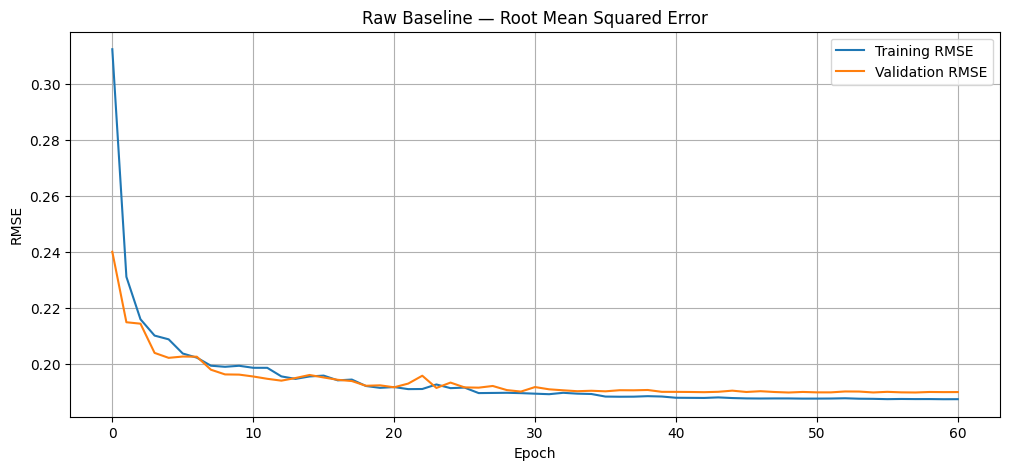

In [125]:
plt.plot(
    raw_history.history["rmse"],
    label="Training RMSE"
)

plt.plot(
    raw_history.history["val_rmse"],
    label="Validation RMSE"
)

plt.title("Raw Baseline — Root Mean Squared Error")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()

plt.show()

## Best Validation Epoch Metrics

The metrics corresponding to the minimum validation loss are extracted directly from the training history.

This provides a compact numerical summary of the best validation-stage performance achieved during the raw baseline experiment.

In [126]:
best_idx = raw_best_epoch - 1

print(
    "Best validation MSE:",
    f"{raw_history.history['val_loss'][best_idx]:.6f}"
)

print(
    "Best validation MAE:",
    f"{raw_history.history['val_mae'][best_idx]:.6f}"
)

print(
    "Best validation RMSE:",
    f"{raw_history.history['val_rmse'][best_idx]:.6f}"
)

Best validation MSE: 0.036032
Best validation MAE: 0.104655
Best validation RMSE: 0.189820


## Validation Prediction Sanity Check

A single validation observation is passed through the trained model to verify that the network returns a complete background profile with the expected dimensions.

This is a structural check only. Quantitative test-set evaluation will be performed separately after both preprocessing branches have been trained.

In [127]:
validation_prediction = raw_baseline_model.predict(
    X_val_raw_nn[:1],
    verbose=0
)

print(
    "Input shape:",
    X_val_raw_nn[:1].shape
)

print(
    "Prediction shape:",
    validation_prediction.shape
)

print(
    "Target shape:",
    y_val_raw_nn[:1].shape
)

Input shape: (1, 1024, 1)
Prediction shape: (1, 1024, 1)
Target shape: (1, 1024, 1)


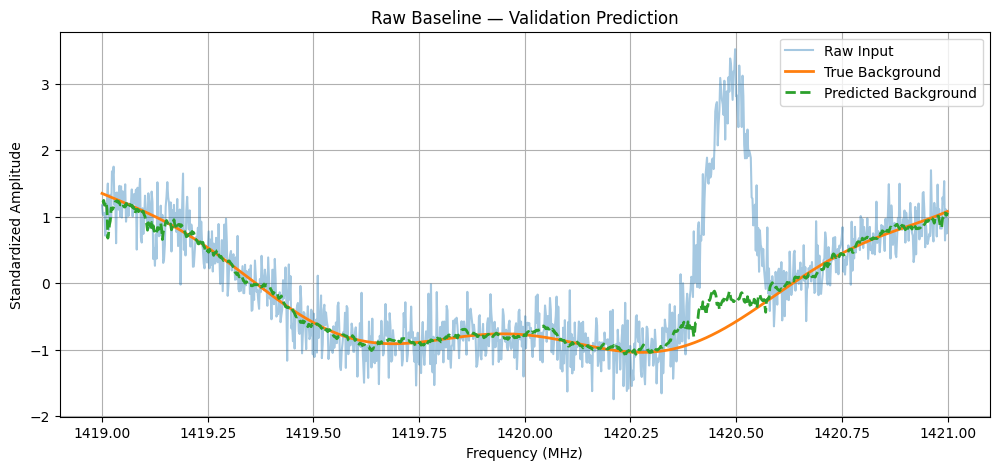

In [128]:
validation_idx = 0

plt.plot(
    freq,
    X_val_raw_std[validation_idx],
    label="Raw Input",
    alpha=0.4
)

plt.plot(
    freq,
    y_val_raw_std[validation_idx],
    label="True Background",
    linewidth=2
)

plt.plot(
    freq,
    validation_prediction[0, :, 0],
    label="Predicted Background",
    linestyle="--",
    linewidth=2
)

plt.title("Raw Baseline — Validation Prediction")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Standardized Amplitude")
plt.legend()

plt.show()

## Step 25 Summary

The baseline 1D CNN was trained using the standardized raw synthetic observations.

The initial model weights were preserved for reuse in the Savitzky–Golay experiment, enabling both preprocessing branches to begin from the same network initialization.

Training was controlled using validation-based early stopping and adaptive learning-rate reduction.

The MSE, MAE, and RMSE histories were inspected across the completed epochs, and the best validation-stage metrics were extracted.

A validation prediction confirmed that the trained model produces a complete channel-aligned background estimate with the expected output dimensions.

The raw baseline model is now ready for final test-set evaluation after the corresponding smoothed baseline experiment has been completed.

# Step 26 — Smoothed Baseline Model Training

The second baseline experiment trains the same 1D CNN architecture using the standardized Savitzky–Golay observations.

To isolate the effect of preprocessing, the smoothed model is initialized with the exact same weights that were stored before the raw baseline training run.

The model architecture, optimizer configuration, training duration, callbacks, batch size, and dataset partitions therefore remain unchanged.

The only experimental difference between the two baseline models is the input preprocessing branch.

## Initial Weight Restoration

The initial baseline weights stored before the raw experiment are assigned to the smoothed model.

This ensures that both experiments begin from the same network parameters and prevents random initialization from affecting the preprocessing comparison.

In [129]:
smoothed_baseline_model.set_weights(
    initial_baseline_weights
)

print(
    "Initial baseline weights restored "
    "to the smoothed model."
)

Initial baseline weights restored to the smoothed model.


In [130]:
weights_match = all(
    np.array_equal(current_weight, initial_weight)
    for current_weight, initial_weight in zip(
        smoothed_baseline_model.get_weights(),
        initial_baseline_weights
    )
)

print(
    "Smoothed model matches the stored "
    f"initial weights: {weights_match}"
)

Smoothed model matches the stored initial weights: True


## Smoothed Baseline Training

The smoothed baseline model is trained using the standardized Savitzky–Golay TensorFlow dataset.

Validation performance is monitored after each epoch using the same early-stopping and learning-rate scheduling rules applied to the raw baseline experiment.

In [131]:
smoothed_history = smoothed_baseline_model.fit(
    train_smoothed_ds,
    validation_data=val_smoothed_ds,
    epochs=MAX_EPOCHS,
    callbacks=create_training_callbacks(),
    verbose=1
)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.1036 - mae: 0.1842 - rmse: 0.3219 - val_loss: 0.0480 - val_mae: 0.1197 - val_rmse: 0.2192 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0466 - mae: 0.1171 - rmse: 0.2158 - val_loss: 0.0420 - val_mae: 0.1092 - val_rmse: 0.2050 - learning_rate: 0.0010
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0423 - mae: 0.1099 - rmse: 0.2058 - val_loss: 0.0397 - val_mae: 0.1077 - val_rmse: 0.1993 - learning_rate: 0.0010
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0402 - mae: 0.1072 - rmse: 0.2005 - val_loss: 0.0369 - val_mae: 0.1037 - val_rmse: 0.1921 - learning_rate: 0.0010
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0383 - mae: 0.1060 - rmse: 0.1957 - val_loss: 0.0377 - val_mae: 0.1013 - val_rmse: 0.1942 - learning_rate: 0.0010
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0375 - mae: 0.1050 - rmse: 0.1937 - val_loss: 

## Training Run Summary

The smoothed-model training history is inspected to identify the number of completed epochs and the epoch corresponding to the minimum validation loss.

Because early stopping restores the best model weights, the final trained model corresponds to the best validation-stage state rather than necessarily the final recorded epoch.

In [132]:
smoothed_epochs_trained = len(
    smoothed_history.history["loss"]
)

smoothed_best_epoch = (
    np.argmin(
        smoothed_history.history["val_loss"]
    )
    + 1
)

smoothed_best_val_loss = np.min(
    smoothed_history.history["val_loss"]
)

print(
    f"Completed epochs: {smoothed_epochs_trained}"
)

print(
    f"Best validation epoch: {smoothed_best_epoch}"
)

print(
    "Best validation MSE:",
    f"{smoothed_best_val_loss:.6f}"
)

Completed epochs: 83
Best validation epoch: 71
Best validation MSE: 0.030845


## Training and Validation Loss

The training and validation MSE curves are inspected to evaluate convergence of the smoothed baseline model.

The behavior of these curves will later be compared directly with the raw baseline experiment to determine whether Savitzky–Golay preprocessing improves background estimation.

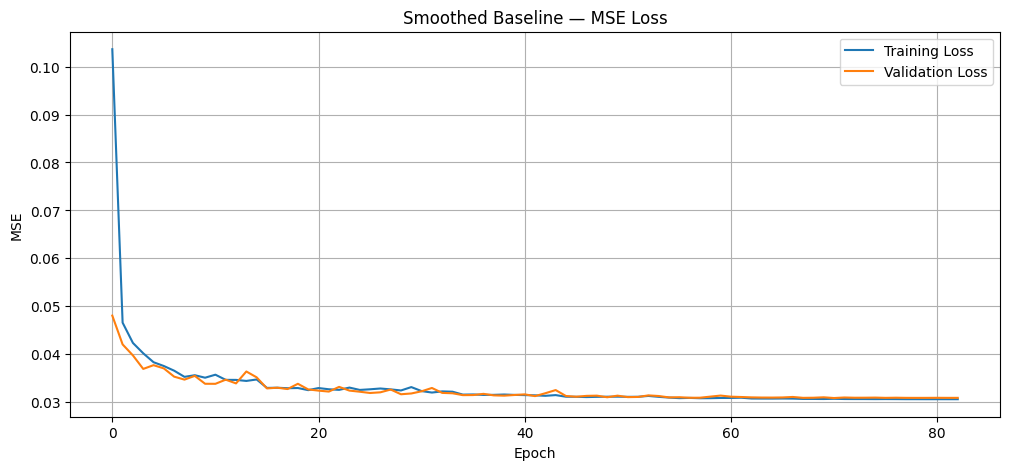

In [133]:
plt.plot(
    smoothed_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    smoothed_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Smoothed Baseline — MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.show()

## Mean Absolute Error

The MAE history is inspected as a complementary regression metric.

It measures the average absolute channel-wise difference between the predicted and target standardized background profiles.

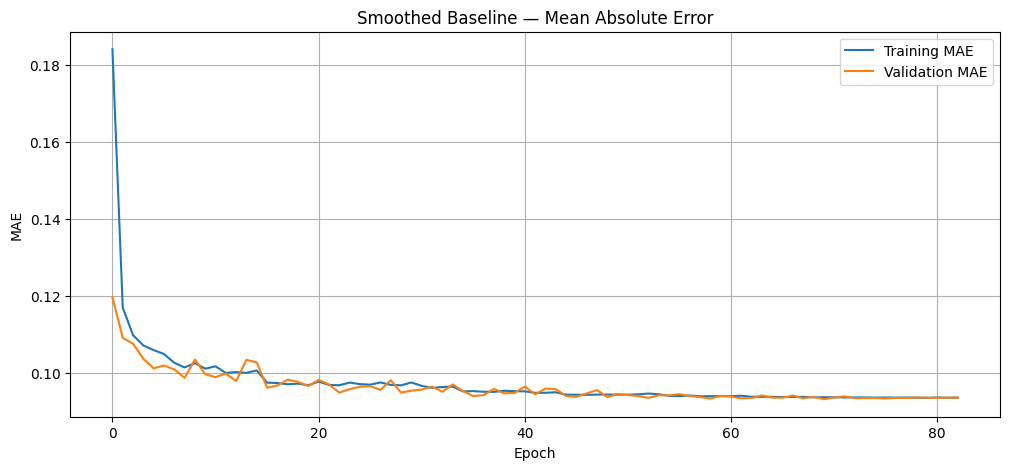

In [134]:
plt.plot(
    smoothed_history.history["mae"],
    label="Training MAE"
)

plt.plot(
    smoothed_history.history["val_mae"],
    label="Validation MAE"
)

plt.title("Smoothed Baseline — Mean Absolute Error")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.show()

## Root Mean Squared Error

The RMSE history is monitored throughout training to track prediction error in the standardized output scale.

The validation RMSE will later be compared with the raw baseline and complemented by test-set evaluation in the original amplitude scale.

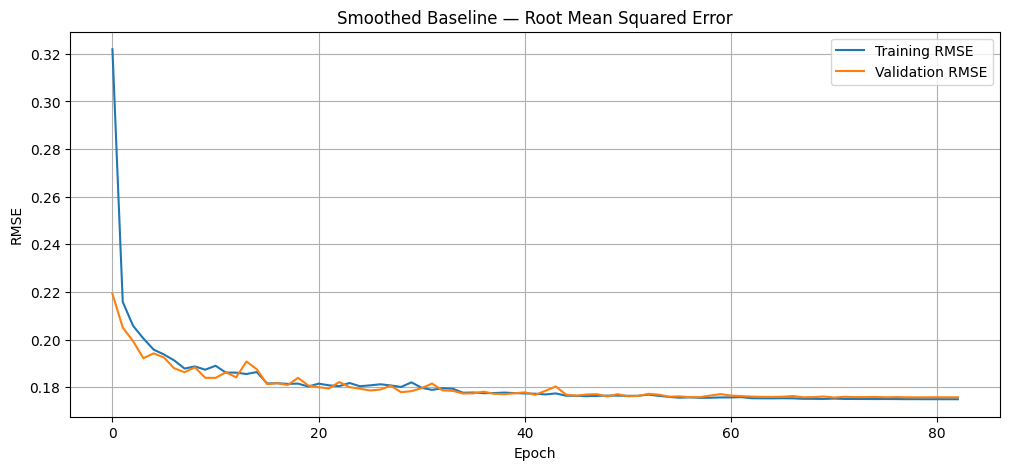

In [135]:
plt.plot(
    smoothed_history.history["rmse"],
    label="Training RMSE"
)

plt.plot(
    smoothed_history.history["val_rmse"],
    label="Validation RMSE"
)

plt.title("Smoothed Baseline — Root Mean Squared Error")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()

plt.show()

## Best Validation Epoch Metrics

The metrics corresponding to the minimum validation loss are extracted from the training history.

These values provide the validation-stage summary of the smoothed baseline experiment.

In [136]:
smoothed_best_idx = (
    smoothed_best_epoch - 1
)

print(
    "Best validation MSE:",
    f"{smoothed_history.history['val_loss'][smoothed_best_idx]:.6f}"
)

print(
    "Best validation MAE:",
    f"{smoothed_history.history['val_mae'][smoothed_best_idx]:.6f}"
)

print(
    "Best validation RMSE:",
    f"{smoothed_history.history['val_rmse'][smoothed_best_idx]:.6f}"
)

Best validation MSE: 0.030845
Best validation MAE: 0.093710
Best validation RMSE: 0.175627


## Validation Prediction Sanity Check

A single smoothed validation observation is passed through the trained model.

The prediction is compared with the standardized smooth-background target to verify that the network produces a complete background profile and does not simply reproduce the spectral-line structure.

In [137]:
smoothed_validation_prediction = (
    smoothed_baseline_model.predict(
        X_val_smoothed_nn[:1],
        verbose=0
    )
)

print(
    "Input shape:",
    X_val_smoothed_nn[:1].shape
)

print(
    "Prediction shape:",
    smoothed_validation_prediction.shape
)

print(
    "Target shape:",
    y_val_smoothed_nn[:1].shape
)

Input shape: (1, 1024, 1)
Prediction shape: (1, 1024, 1)
Target shape: (1, 1024, 1)


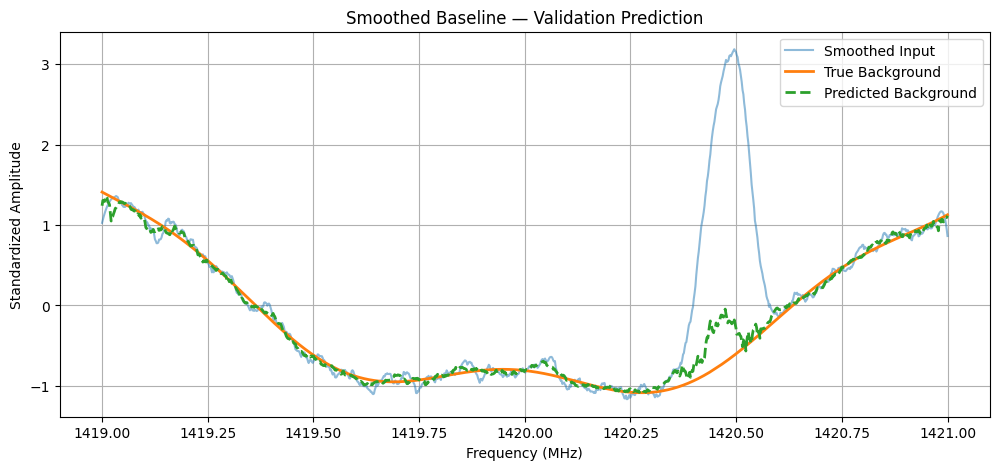

In [138]:
validation_idx = 0

plt.plot(
    freq,
    X_val_smoothed_std[validation_idx],
    label="Smoothed Input",
    alpha=0.5
)

plt.plot(
    freq,
    y_val_smoothed_std[validation_idx],
    label="True Background",
    linewidth=2
)

plt.plot(
    freq,
    smoothed_validation_prediction[0, :, 0],
    label="Predicted Background",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Smoothed Baseline — Validation Prediction"
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Standardized Amplitude")
plt.legend()

plt.show()

## Baseline Validation Comparison

The best validation-stage metrics from the raw and Savitzky–Golay experiments are compared directly.

Because both models use the same architecture, initialization, dataset split, optimizer, and training configuration, differences in performance can be primarily attributed to the preprocessing branch.

In [139]:
print("Raw baseline")
print(
    "  Best MSE:",
    f"{raw_history.history['val_loss'][best_idx]:.6f}"
)
print(
    "  Best MAE:",
    f"{raw_history.history['val_mae'][best_idx]:.6f}"
)
print(
    "  Best RMSE:",
    f"{raw_history.history['val_rmse'][best_idx]:.6f}"
)

print("\nSmoothed baseline")
print(
    "  Best MSE:",
    f"{smoothed_history.history['val_loss'][smoothed_best_idx]:.6f}"
)
print(
    "  Best MAE:",
    f"{smoothed_history.history['val_mae'][smoothed_best_idx]:.6f}"
)
print(
    "  Best RMSE:",
    f"{smoothed_history.history['val_rmse'][smoothed_best_idx]:.6f}"
)

Raw baseline
  Best MSE: 0.036032
  Best MAE: 0.104655
  Best RMSE: 0.189820

Smoothed baseline
  Best MSE: 0.030845
  Best MAE: 0.093710
  Best RMSE: 0.175627


## Step 26 Summary

The baseline 1D CNN was trained using the standardized Savitzky–Golay observations.

Before training, the stored initial network weights were restored so that the raw and smoothed baseline experiments began from identical model parameters.

The same architecture, optimizer, callbacks, batch size, and dataset partitions were maintained across both experiments.

Training and validation MSE, MAE, and RMSE were inspected, and the best validation-stage metrics were extracted.

A validation prediction confirmed that the smoothed model produces a complete channel-aligned background estimate.

The raw and smoothed baseline models are now ready for evaluation on the independent test set.

# Step 27 — Final Test Evaluation and Raw vs Smoothed Comparison

The trained raw and Savitzky–Golay baseline models are now evaluated on the independent test set.

Model predictions are initially produced in the standardized coordinate system used during training.

For each test observation, the corresponding stored input mean and standard deviation are therefore used to transform the predicted background back to the original amplitude scale.

The reconstructed predictions are then compared with the original smooth-background targets using:

- Mean Squared Error (MSE),
- Root Mean Squared Error (RMSE),
- coefficient of determination (R²).

Both preprocessing branches are evaluated using the same test observations and the same original background targets.

## Test-Set Prediction

Both trained baseline models generate background estimates for their corresponding standardized test inputs.

The test partition remains unchanged and was not used during model training or callback monitoring.

In [140]:
raw_test_predictions_std = raw_baseline_model.predict(
    X_test_raw_nn,
    verbose=1
)

smoothed_test_predictions_std = smoothed_baseline_model.predict(
    X_test_smoothed_nn,
    verbose=1
)

print(
    "Raw prediction shape:",
    raw_test_predictions_std.shape
)

print(
    "Smoothed prediction shape:",
    smoothed_test_predictions_std.shape
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Raw prediction shape: (750, 1024, 1)
Smoothed prediction shape: (750, 1024, 1)


## Prediction Shape Preparation

The final singleton feature dimension is removed before inverse transformation and metric calculation.

This restores the predictions to the original two-dimensional dataset structure:

(samples, spectral channels)

In [141]:
raw_test_predictions_std = np.squeeze(
    raw_test_predictions_std,
    axis=-1
)

smoothed_test_predictions_std = np.squeeze(
    smoothed_test_predictions_std,
    axis=-1
)

print(
    "Raw prediction shape:",
    raw_test_predictions_std.shape
)

print(
    "Smoothed prediction shape:",
    smoothed_test_predictions_std.shape
)

Raw prediction shape: (750, 1024)
Smoothed prediction shape: (750, 1024)


## Prediction Inverse Transformation

The standardized model outputs are transformed back to the original amplitude scale.

Each prediction is reconstructed using the mean and standard deviation of the corresponding test input.

The raw and smoothed branches require their own stored statistics because their preprocessing transformations were performed independently.

In [142]:
raw_test_predictions = (
    raw_test_predictions_std
    * raw_test_stds
    + raw_test_means
)

smoothed_test_predictions = (
    smoothed_test_predictions_std
    * smoothed_test_stds
    + smoothed_test_means
)

raw_test_predictions = raw_test_predictions.astype(
    np.float32
)

smoothed_test_predictions = (
    smoothed_test_predictions.astype(np.float32)
)

## Inverse-Transformation Verification

The reconstructed predictions are checked for the expected dimensions and valid numerical values before metric calculation.

In [143]:
print(
    "Raw reconstructed predictions:",
    raw_test_predictions.shape
)

print(
    "Smoothed reconstructed predictions:",
    smoothed_test_predictions.shape
)

print(
    "Original test targets:",
    y_test_smooth.shape
)

assert (
    raw_test_predictions.shape
    == y_test_smooth.shape
)

assert (
    smoothed_test_predictions.shape
    == y_test_smooth.shape
)

assert np.all(
    np.isfinite(raw_test_predictions)
)

assert np.all(
    np.isfinite(smoothed_test_predictions)
)

print(
    "All reconstructed predictions are valid."
)

Raw reconstructed predictions: (750, 1024)
Smoothed reconstructed predictions: (750, 1024)
Original test targets: (750, 1024)
All reconstructed predictions are valid.


## Test Metric Calculation

A reusable evaluation function calculates MSE, RMSE, and R² from the reconstructed predictions.

The complete test arrays are flattened so that every spectral-channel prediction contributes to the dataset-level performance estimate.

In [144]:
def calculate_regression_metrics(
    y_true,
    y_pred
):
    """
    Calculate dataset-level regression metrics.

    Parameters
    ----------
    y_true : np.ndarray
        Original smooth-background targets.
    y_pred : np.ndarray
        Predicted backgrounds in the original amplitude scale.

    Returns
    -------
    dict
        MSE, RMSE, and R² values.
    """
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    mse = mean_squared_error(
        y_true_flat,
        y_pred_flat
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true_flat,
        y_pred_flat
    )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [145]:
raw_test_metrics = calculate_regression_metrics(
    y_test_smooth,
    raw_test_predictions
)

smoothed_test_metrics = (
    calculate_regression_metrics(
        y_test_smooth,
        smoothed_test_predictions
    )
)

## Final Test Metrics

The reconstructed predictions from both preprocessing branches are evaluated against the same original smooth-background targets.

Lower MSE and RMSE values indicate smaller prediction errors, while an R² value closer to 1 indicates that the predicted background explains more of the variation present in the true background.

In [146]:
print("Raw baseline test metrics")

print(
    f"  MSE:  "
    f"{raw_test_metrics['MSE']:.8f}"
)

print(
    f"  RMSE: "
    f"{raw_test_metrics['RMSE']:.8f}"
)

print(
    f"  R²:   "
    f"{raw_test_metrics['R2']:.6f}"
)

print("\nSmoothed baseline test metrics")

print(
    f"  MSE:  "
    f"{smoothed_test_metrics['MSE']:.8f}"
)

print(
    f"  RMSE: "
    f"{smoothed_test_metrics['RMSE']:.8f}"
)

print(
    f"  R²:   "
    f"{smoothed_test_metrics['R2']:.6f}"
)

Raw baseline test metrics
  MSE:  0.00002149
  RMSE: 0.00463573
  R²:   0.997357

Smoothed baseline test metrics
  MSE:  0.00001448
  RMSE: 0.00380541
  R²:   0.998219


## Per-Spectrum Performance

Dataset-level metrics summarize all spectral channels simultaneously but do not describe the variation in performance between individual observations.

MSE, RMSE, and R² are therefore also calculated independently for every test spectrum.

The resulting distributions provide a more detailed view of model consistency across different synthetic background morphologies.

In [147]:
def calculate_per_spectrum_metrics(
    y_true,
    y_pred
):
    """
    Calculate regression metrics independently
    for each spectrum.
    """
    mse_values = np.mean(
        (y_true - y_pred) ** 2,
        axis=1
    )

    rmse_values = np.sqrt(
        mse_values
    )

    r2_values = np.array(
        [
            r2_score(
                y_true[idx],
                y_pred[idx]
            )
            for idx in range(len(y_true))
        ]
    )

    return (
        mse_values,
        rmse_values,
        r2_values
    )

In [148]:
(
    raw_mse_per_spectrum,
    raw_rmse_per_spectrum,
    raw_r2_per_spectrum
) = calculate_per_spectrum_metrics(
    y_test_smooth,
    raw_test_predictions
)

(
    smoothed_mse_per_spectrum,
    smoothed_rmse_per_spectrum,
    smoothed_r2_per_spectrum
) = calculate_per_spectrum_metrics(
    y_test_smooth,
    smoothed_test_predictions
)

In [149]:
print("Raw baseline — Mean per-spectrum metrics")

print(
    "  Mean MSE:",
    f"{np.mean(raw_mse_per_spectrum):.8f}"
)

print(
    "  Mean RMSE:",
    f"{np.mean(raw_rmse_per_spectrum):.8f}"
)

print(
    "  Mean R²:",
    f"{np.mean(raw_r2_per_spectrum):.6f}"
)

print("\nSmoothed baseline — Mean per-spectrum metrics")

print(
    "  Mean MSE:",
    f"{np.mean(smoothed_mse_per_spectrum):.8f}"
)

print(
    "  Mean RMSE:",
    f"{np.mean(smoothed_rmse_per_spectrum):.8f}"
)

print(
    "  Mean R²:",
    f"{np.mean(smoothed_r2_per_spectrum):.6f}"
)

Raw baseline — Mean per-spectrum metrics
  Mean MSE: 0.00002149
  Mean RMSE: 0.00422343
  Mean R²: 0.850680

Smoothed baseline — Mean per-spectrum metrics
  Mean MSE: 0.00001448
  Mean RMSE: 0.00345406
  Mean R²: 0.898139


## Raw Baseline Test Prediction

A representative test observation is visualized in the original amplitude scale.

The predicted background is compared directly with the known synthetic smooth-background target and the complete noisy observation.

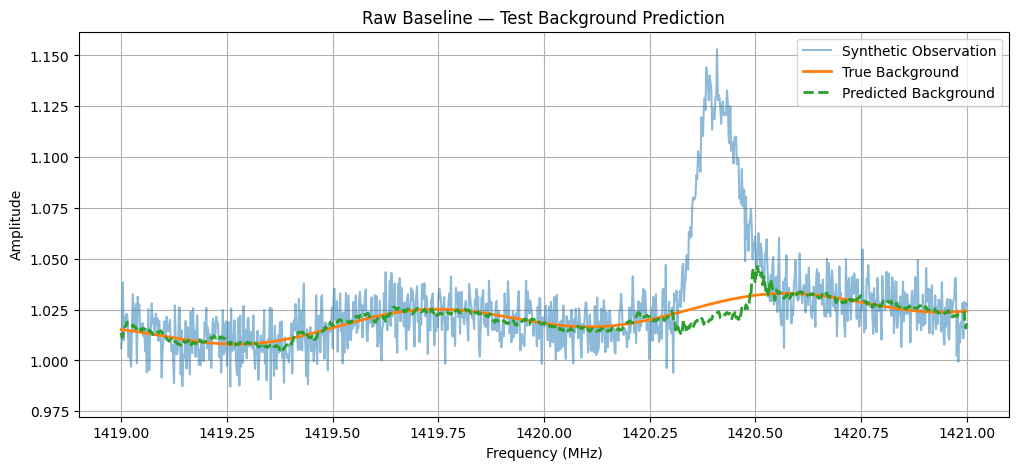

In [150]:
test_idx = 0

plt.plot(
    freq,
    X_test_raw[test_idx],
    label="Synthetic Observation",
    alpha=0.5
)

plt.plot(
    freq,
    y_test_smooth[test_idx],
    label="True Background",
    linewidth=2
)

plt.plot(
    freq,
    raw_test_predictions[test_idx],
    label="Predicted Background",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Raw Baseline — Test Background Prediction"
)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Smoothed Baseline Test Prediction

The corresponding Savitzky–Golay test prediction is visualized using the same synthetic observation index.

This allows both preprocessing branches to be inspected against the same underlying smooth-background target.

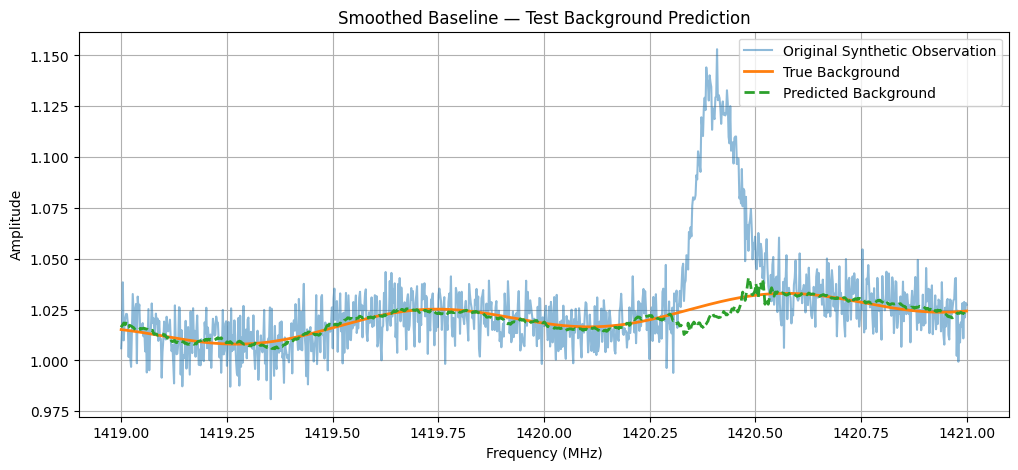

In [151]:
plt.plot(
    freq,
    X_test_raw[test_idx],
    label="Original Synthetic Observation",
    alpha=0.5
)

plt.plot(
    freq,
    y_test_smooth[test_idx],
    label="True Background",
    linewidth=2
)

plt.plot(
    freq,
    smoothed_test_predictions[test_idx],
    label="Predicted Background",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Smoothed Baseline — Test Background Prediction"
)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Background Prediction Residual

The difference between the predicted and true smooth backgrounds is inspected across the frequency axis.

A residual centered near zero with small variations indicates that the model follows the underlying background profile without systematically overestimating or underestimating it.

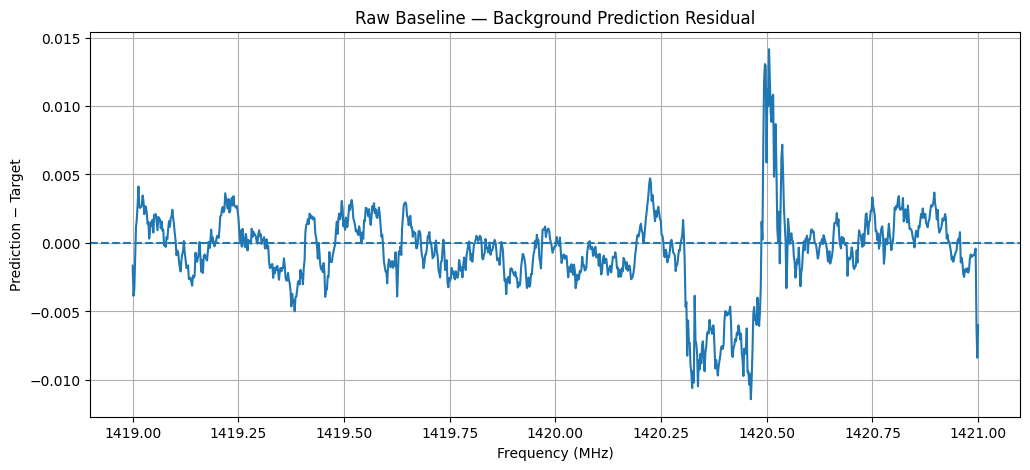

In [152]:
raw_background_residual = (
    raw_test_predictions[test_idx]
    - y_test_smooth[test_idx]
)

plt.plot(
    freq,
    raw_background_residual
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.title(
    "Raw Baseline — Background Prediction Residual"
)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Prediction − Target")

plt.show()

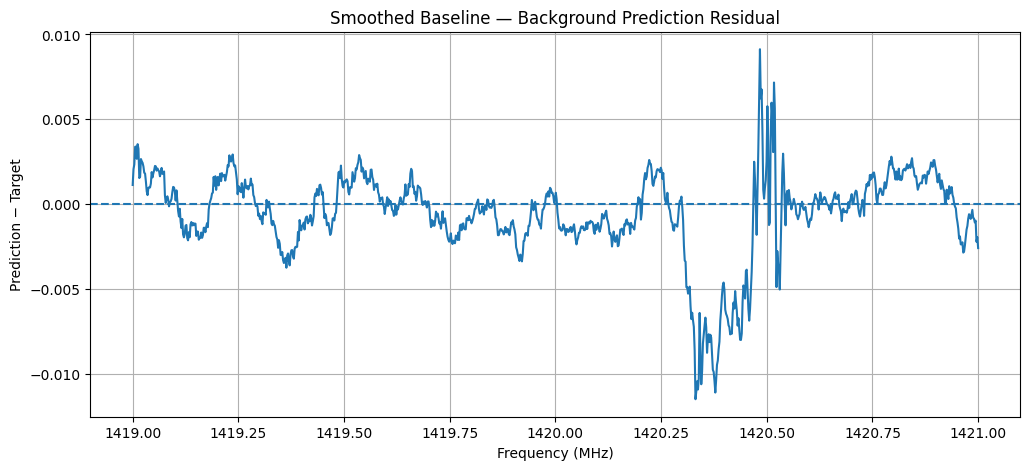

In [153]:
smoothed_background_residual = (
    smoothed_test_predictions[test_idx]
    - y_test_smooth[test_idx]
)

plt.plot(
    freq,
    smoothed_background_residual
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.title(
    "Smoothed Baseline — Background Prediction Residual"
)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Prediction − Target")

plt.show()

## Step 27 Summary

The raw and Savitzky–Golay baseline models were evaluated on the independent test partition.

Standardized model outputs were transformed back to the original amplitude scale using the stored preprocessing statistics of each test observation.

Final background-estimation performance was quantified using MSE, RMSE, and R², following the evaluation criteria defined for the project.

Metrics were calculated both across the complete test dataset and independently for each spectrum to assess overall accuracy and sample-to-sample consistency.

Representative predictions and residuals were also inspected in the original signal scale.

The baseline evaluation is now complete and provides the reference performance for subsequent neural network experiments.